In [1]:
!pip install lightgbm -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay,
                             average_precision_score)
from sklearn.inspection import permutation_importance

import lightgbm as lgb
from lightgbm import LGBMClassifier, plot_importance, plot_metric

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [2]:
path = kagglehub.dataset_download(
    "teejmahal20/airline-passenger-satisfaction")
print("📁 Path:", path)

train_file = os.path.join(path, "train.csv")
test_file  = os.path.join(path, "test.csv")

df_train = pd.read_csv(train_file)
df_test  = pd.read_csv(test_file)

# Combine for EDA & cleaning
df = pd.concat([df_train, df_test],
               ignore_index=True)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Train Shape : {df_train.shape}")
print(f"📐 Test Shape  : {df_test.shape}")
print(f"📐 Total Shape : {df.shape}")
df.head()

100%|██████████| 2.71M/2.71M [00:01<00:00, 2.11MB/s]

Extracting files...


📁 Path: /root/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1

✅ Dataset Loaded!
📐 Train Shape : (103904, 25)
📐 Test Shape  : (25976, 25)
📐 Total Shape : (129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,129880.0,NaN,NaN,NaN,44158.7,31207.377062,0.0,16234.75,38963.5,71433.25,103903.0
id,129880.0,NaN,NaN,NaN,64940.5,37493.270818,1.0,32470.75,64940.5,97410.25,129880.0
Gender,129880,2,Female,65899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,129880,2,Loyal Customer,106100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,129880.0,NaN,NaN,NaN,39.427957,15.11936,7.0,27.0,40.0,51.0,85.0
Type of Travel,129880,2,Business travel,89693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,129880,3,Business,62160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,129880.0,NaN,NaN,NaN,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Inflight wifi service,129880.0,NaN,NaN,NaN,2.728696,1.32934,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,NaN,NaN,NaN,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0


In [5]:
num_cols = df.select_dtypes(
    include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(
    include=['object']).columns.tolist()

print(f"\n🔢 Numerical ({len(num_cols)}):")
for c in num_cols:
    print(f"   → {c}")

print(f"\n🔤 Categorical ({len(cat_cols)}):")
for c in cat_cols:
    print(f"   → {c}: "
          f"{df[c].unique()[:5]}")

print(f"\n🎯 Target: satisfaction")
print(df['satisfaction'].value_counts())
print(f"\nSatisfied Rate: "
      f"{(df['satisfaction']=='satisfied').mean()*100:.1f}%")


🔢 Numerical (20):
   → Unnamed: 0
   → id
   → Age
   → Flight Distance
   → Inflight wifi service
   → Departure/Arrival time convenient
   → Ease of Online booking
   → Gate location
   → Food and drink
   → Online boarding
   → Seat comfort
   → Inflight entertainment
   → On-board service
   → Leg room service
   → Baggage handling
   → Checkin service
   → Inflight service
   → Cleanliness
   → Departure Delay in Minutes
   → Arrival Delay in Minutes

🔤 Categorical (5):
   → Gender: ['Male' 'Female']
   → Customer Type: ['Loyal Customer' 'disloyal Customer']
   → Type of Travel: ['Personal Travel' 'Business travel']
   → Class: ['Eco Plus' 'Business' 'Eco']
   → satisfaction: ['neutral or dissatisfied' 'satisfied']

🎯 Target: satisfaction
satisfaction
neutral or dissatisfied    73452
satisfied                  56428
Name: count, dtype: int64

Satisfied Rate: 43.4%


In [6]:
id_cols = ['Unnamed: 0', 'id']
id_cols = [c for c in id_cols if c in df.columns]
df.drop(columns=id_cols, inplace=True)
print(f"✅ Dropped ID cols: {id_cols}")

✅ Dropped ID cols: ['Unnamed: 0', 'id']


In [7]:
print("\n🔍 Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("✅ No missing values!")
else:
    print(missing)
    # Fill numeric with median
    for col in missing.index:
        if df[col].dtype in [np.float64, np.int64]:
            df[col].fillna(
                df[col].median(), inplace=True)
            print(f"   → {col}: filled with median "
                  f"({df[col].median():.2f})")
        else:
            df[col].fillna(
                df[col].mode()[0], inplace=True)
            print(f"   → {col}: filled with mode")


🔍 Missing Values:
Arrival Delay in Minutes    393
dtype: int64
   → Arrival Delay in Minutes: filled with median (0.00)


In [8]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups:,}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ {dups:,} duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 0
✅ No duplicates found!


In [9]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(
    lambda x: x.str.strip())
print("✅ Whitespace stripped")

✅ Whitespace stripped


In [10]:
rating_cols = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness']
rating_cols = [c for c in rating_cols
               if c in df.columns]
for col in rating_cols:
    df[col] = pd.to_numeric(
        df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)
print(f"✅ Rating columns converted to numeric")

✅ Rating columns converted to numeric


In [11]:
print("\n🔍 Outlier Detection (IQR):")
num_feat_cols = df.select_dtypes(
    include=[np.number]).columns.tolist()
num_feat_cols = [c for c in num_feat_cols
                 if c != 'satisfaction']
outlier_info = {}

for col in num_feat_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 1.5*IQR) |
             (df[col] > Q3 + 1.5*IQR)].shape[0]
    if out > 0:
        outlier_info[col] = out

print(f"  Columns with outliers: {len(outlier_info)}")
for col in outlier_info:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 1.5*IQR,
        upper=Q3 + 1.5*IQR)
print("✅ Outliers capped (Winsorization)")

print(f"\n📐 Cleaned Shape: {df.shape}")
df.head(3)


🔍 Outlier Detection (IQR):
  Columns with outliers: 4
✅ Outliers capped (Winsorization)

📐 Cleaned Shape: (129880, 23)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4.0,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1.5,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4.0,4,5,0,0.0,satisfied


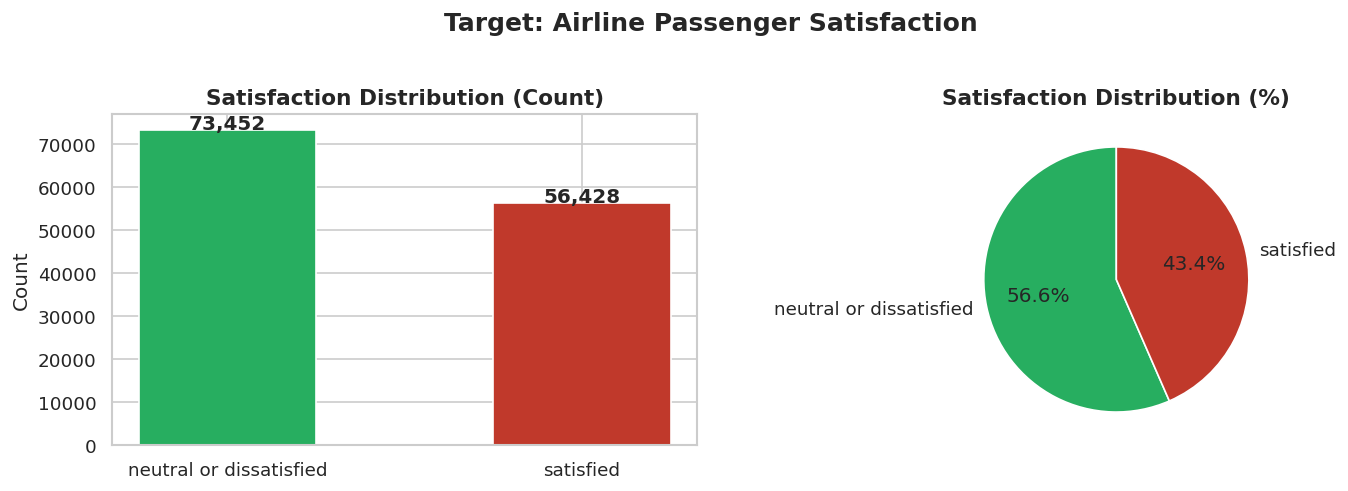

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sat_counts = df['satisfaction'].value_counts()
colors_main = ['#27ae60', '#c0392b']

axes[0].bar(sat_counts.index,
            sat_counts.values,
            color=colors_main,
            edgecolor='white', width=0.5)
axes[0].set_title('Satisfaction Distribution (Count)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sat_counts.values):
    axes[0].text(i, v + 200, f'{v:,}',
                 ha='center', fontweight='bold')

axes[1].pie(sat_counts.values,
            labels=sat_counts.index,
            autopct='%1.1f%%',
            colors=colors_main,
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Satisfaction Distribution (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target: Airline Passenger Satisfaction',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('LGBM_01_satisfaction_dist.png',
            bbox_inches='tight')
plt.show()

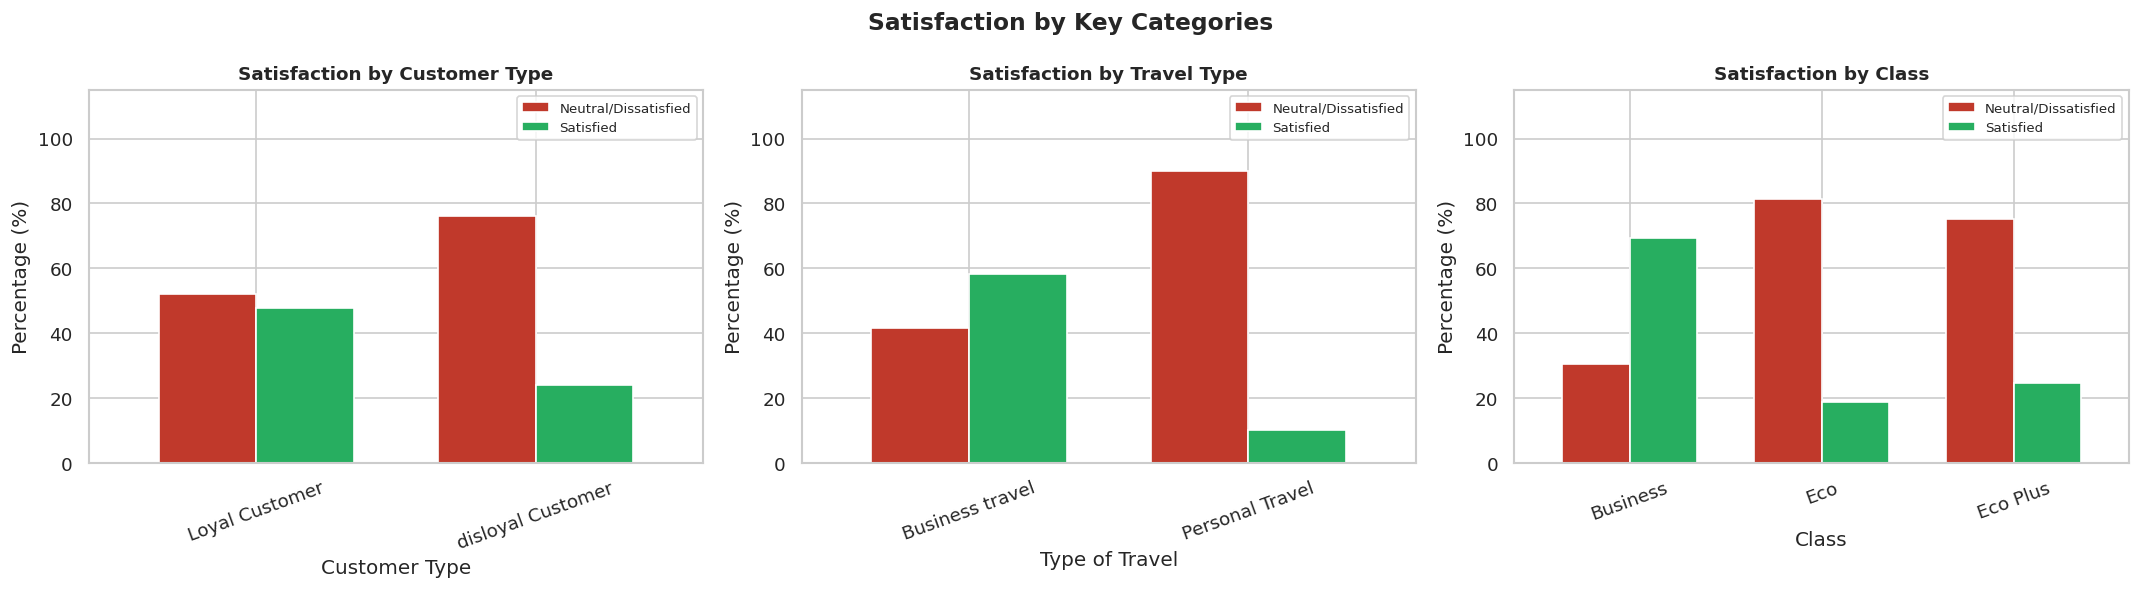

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
        axes,
        ['Customer Type', 'Type of Travel', 'Class'],
        ['Customer Type', 'Travel Type', 'Class']):
    ct = pd.crosstab(
        df[col], df['satisfaction'],
        normalize='index') * 100
    ct.plot(kind='bar', ax=ax,
            color=['#c0392b', '#27ae60'],
            edgecolor='white', width=0.7)
    ax.set_title(f'Satisfaction by {title}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(['Neutral/Dissatisfied',
               'Satisfied'], fontsize=8)
    ax.set_ylim(0, 115)

plt.suptitle('Satisfaction by Key Categories',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('LGBM_02_category_analysis.png',
            bbox_inches='tight')
plt.show()

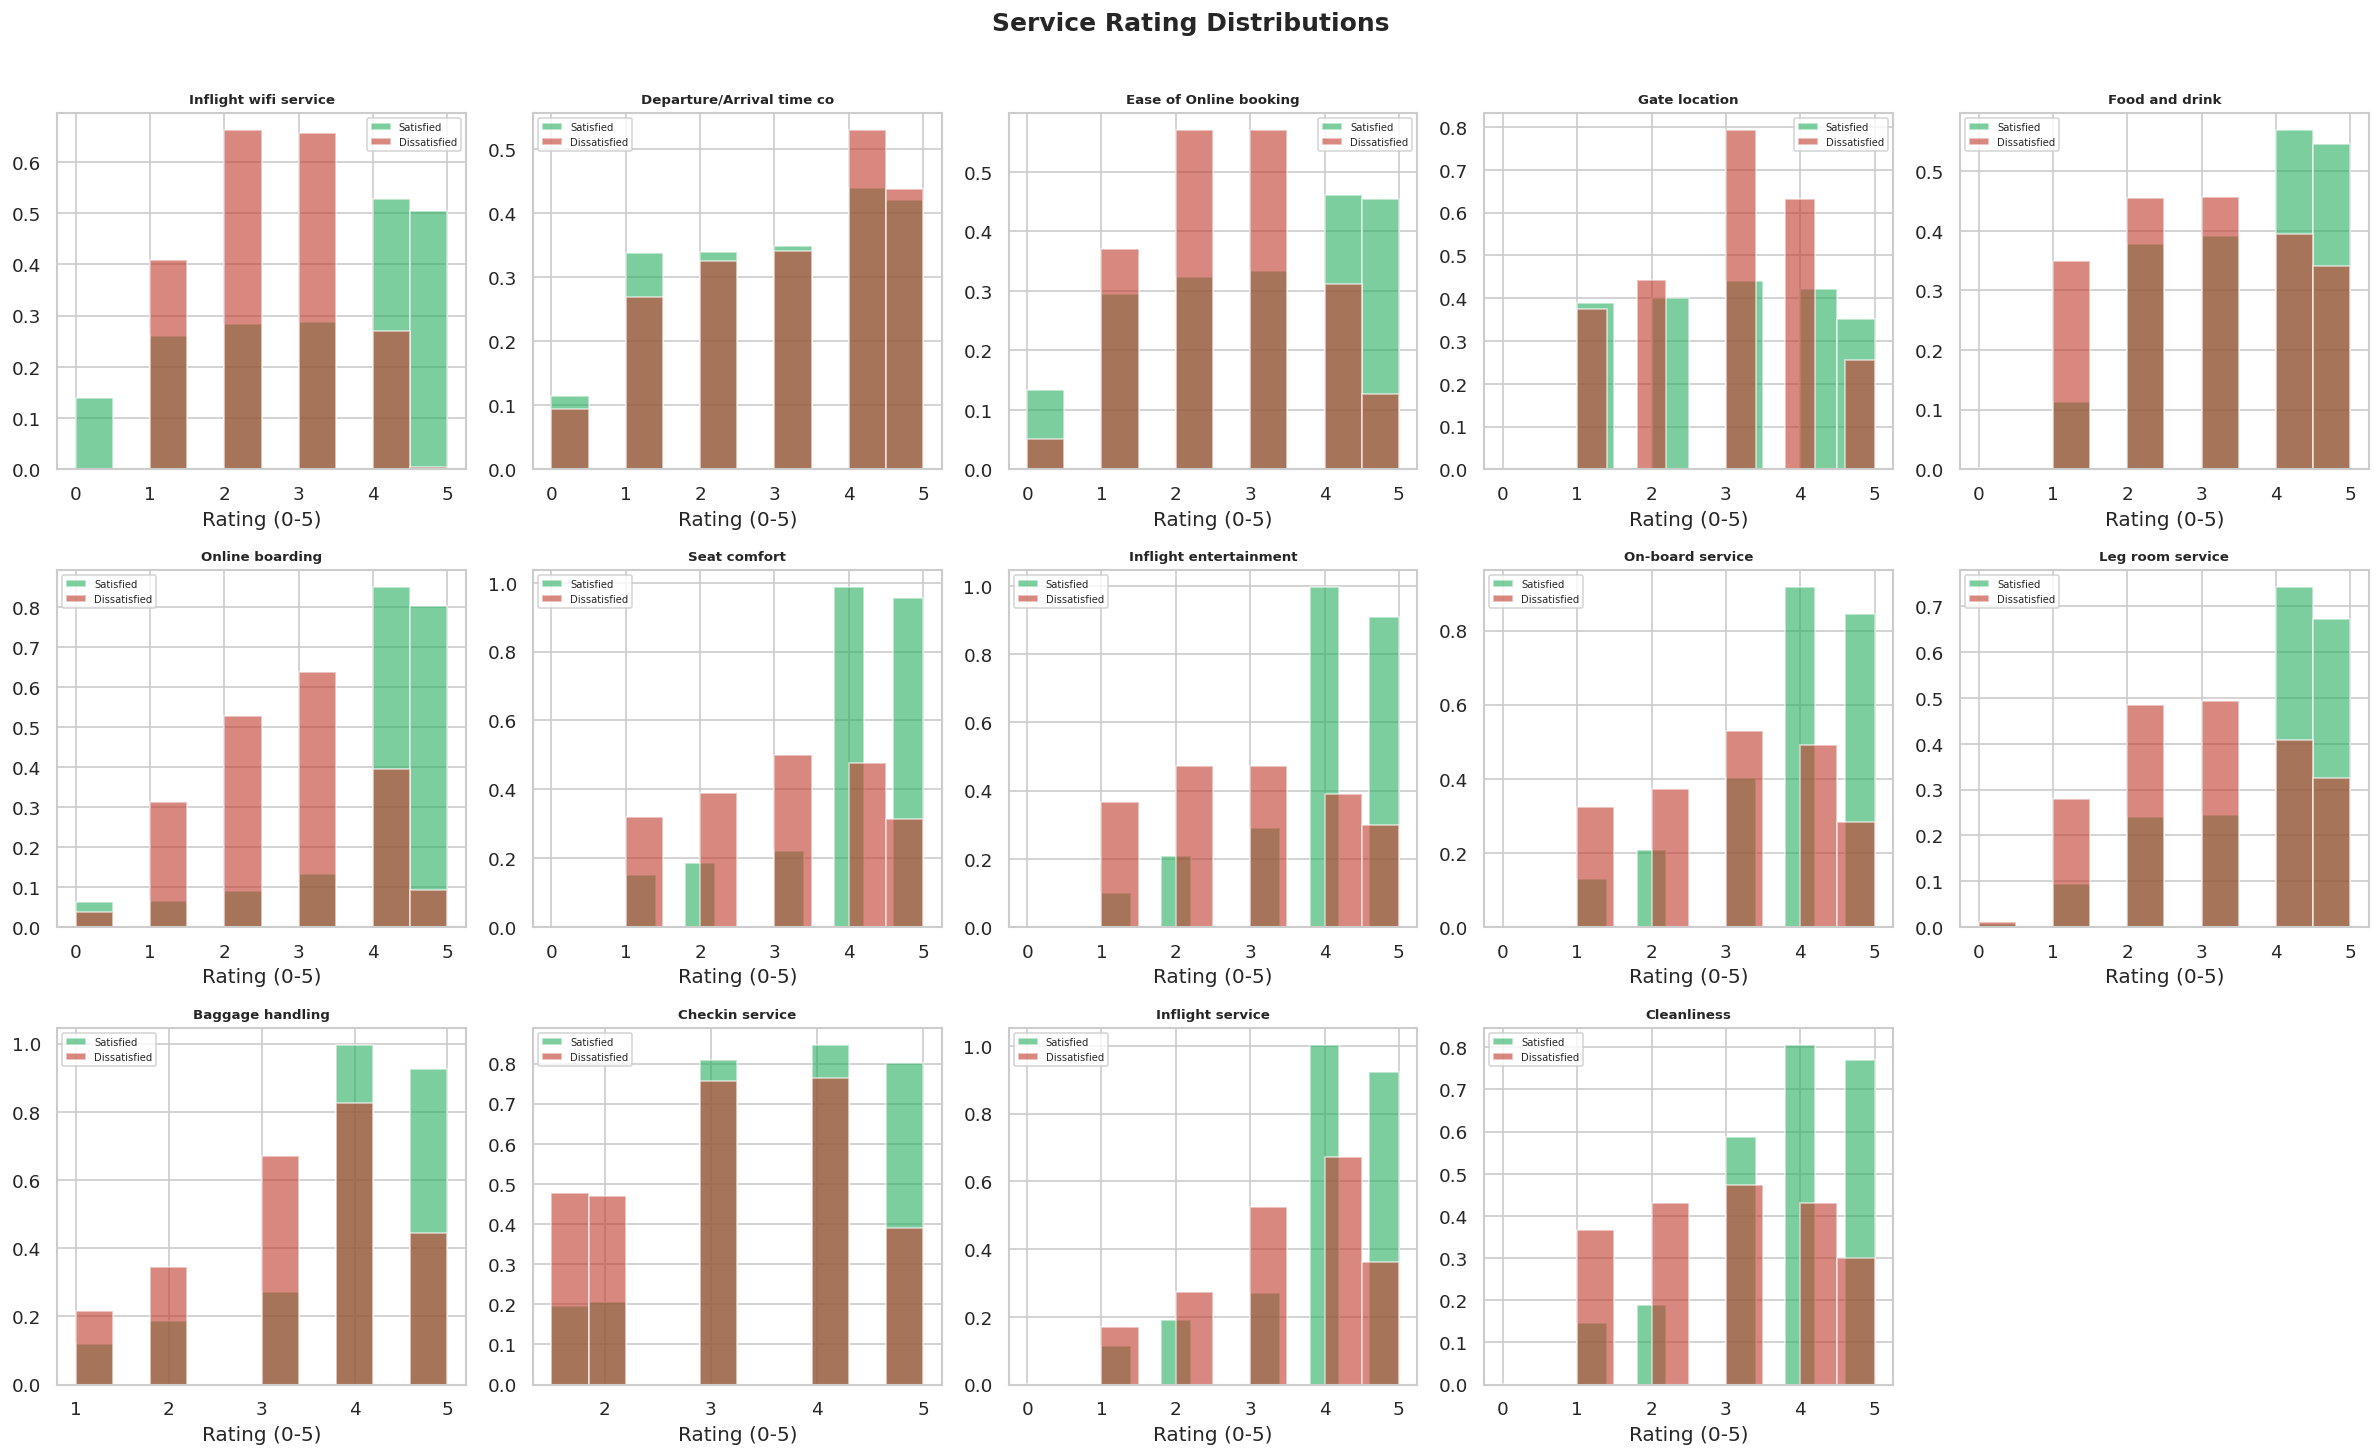

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(rating_cols):
    for label, color, name in zip(
            ['satisfied',
             'neutral or dissatisfied'],
            ['#27ae60', '#c0392b'],
            ['Satisfied', 'Dissatisfied']):
        axes[i].hist(
            df[df['satisfaction']==label][col],
            bins=10, alpha=0.6,
            color=color, label=name,
            density=True)
    axes[i].set_title(col[:25],
                      fontweight='bold',
                      fontsize=8)
    axes[i].set_xlabel('Rating (0-5)')
    axes[i].legend(fontsize=6)

# Hide extra axes
for j in range(len(rating_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Service Rating Distributions',
             fontsize=15, fontweight='bold',
             y=1.01)
plt.tight_layout()
plt.savefig('LGBM_03_rating_distributions.png',
            bbox_inches='tight')
plt.show()

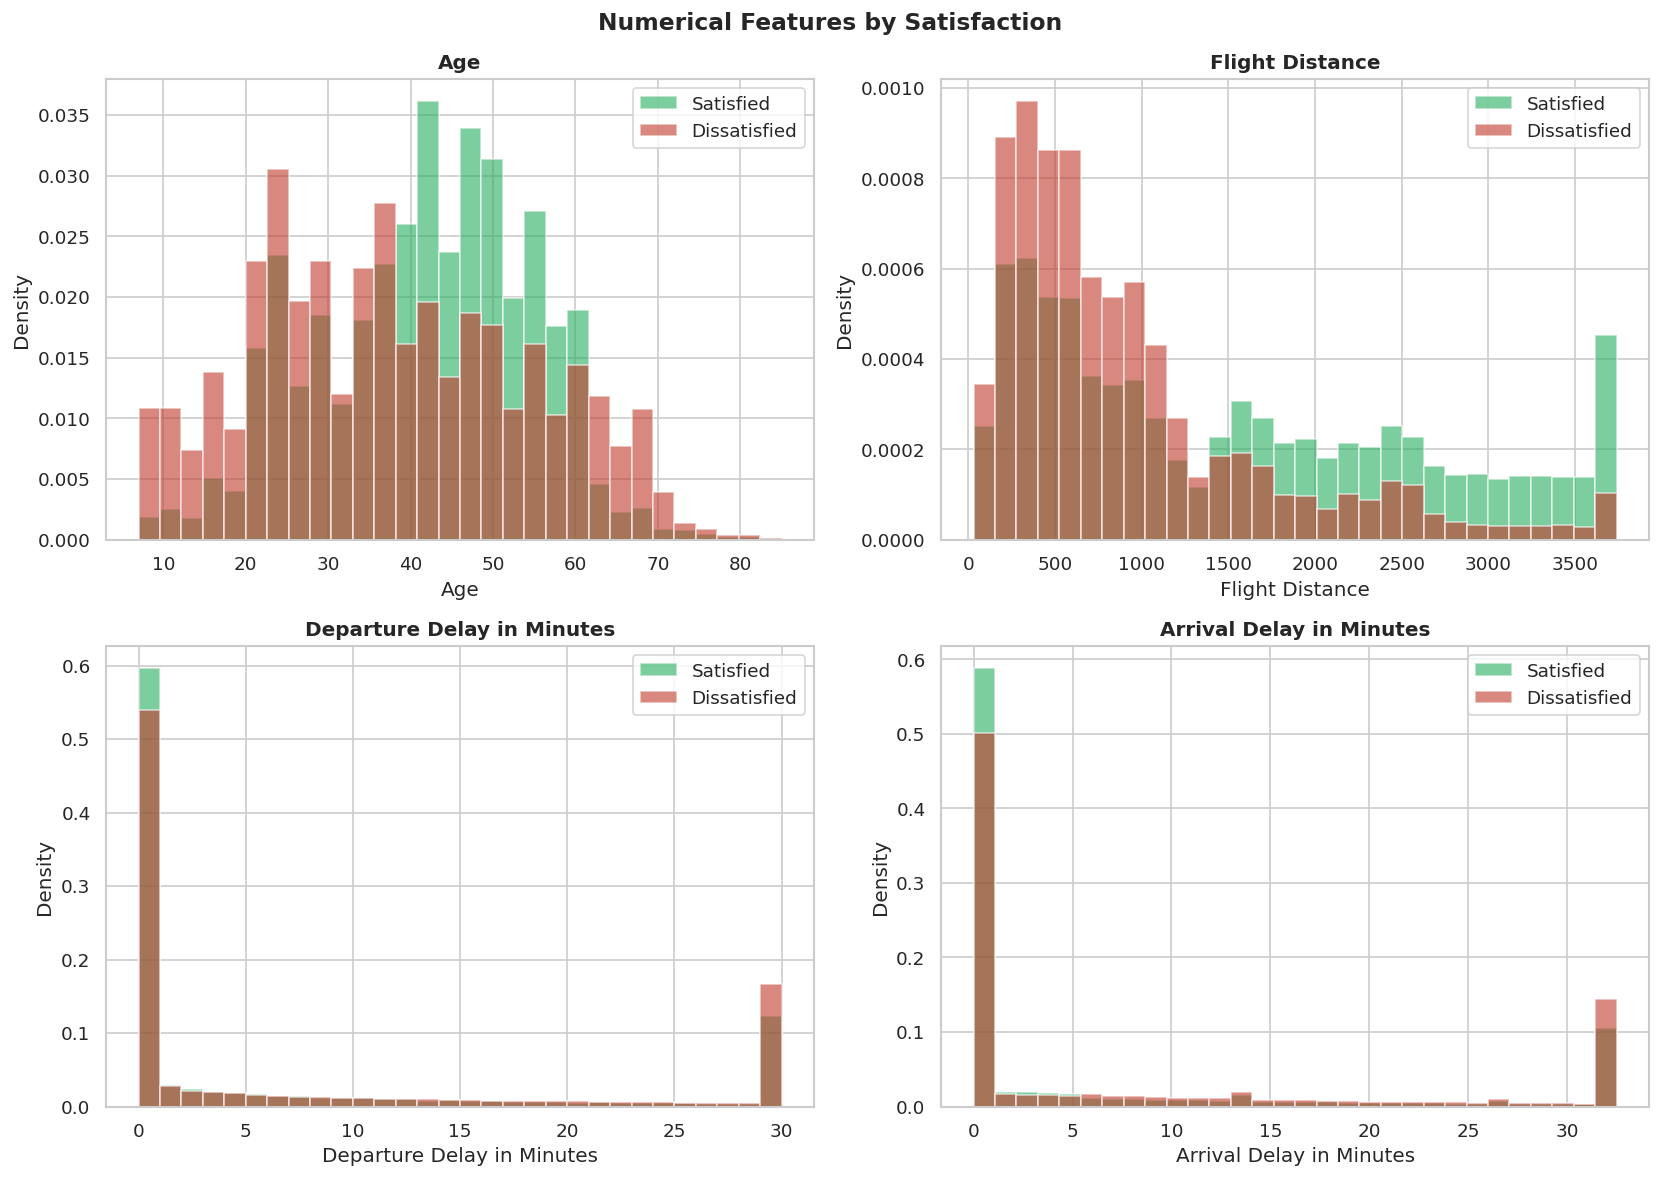

In [15]:
num_plot = ['Age', 'Flight Distance',
            'Departure Delay in Minutes',
            'Arrival Delay in Minutes']
num_plot = [c for c in num_plot
            if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_plot):
    for label, color, name in zip(
            ['satisfied',
             'neutral or dissatisfied'],
            ['#27ae60', '#c0392b'],
            ['Satisfied', 'Dissatisfied']):
        axes[i].hist(
            df[df['satisfaction']==label][col],
            bins=30, alpha=0.6,
            color=color, label=name,
            density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Numerical Features by Satisfaction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('LGBM_04_numerical_dist.png',
            bbox_inches='tight')
plt.show()

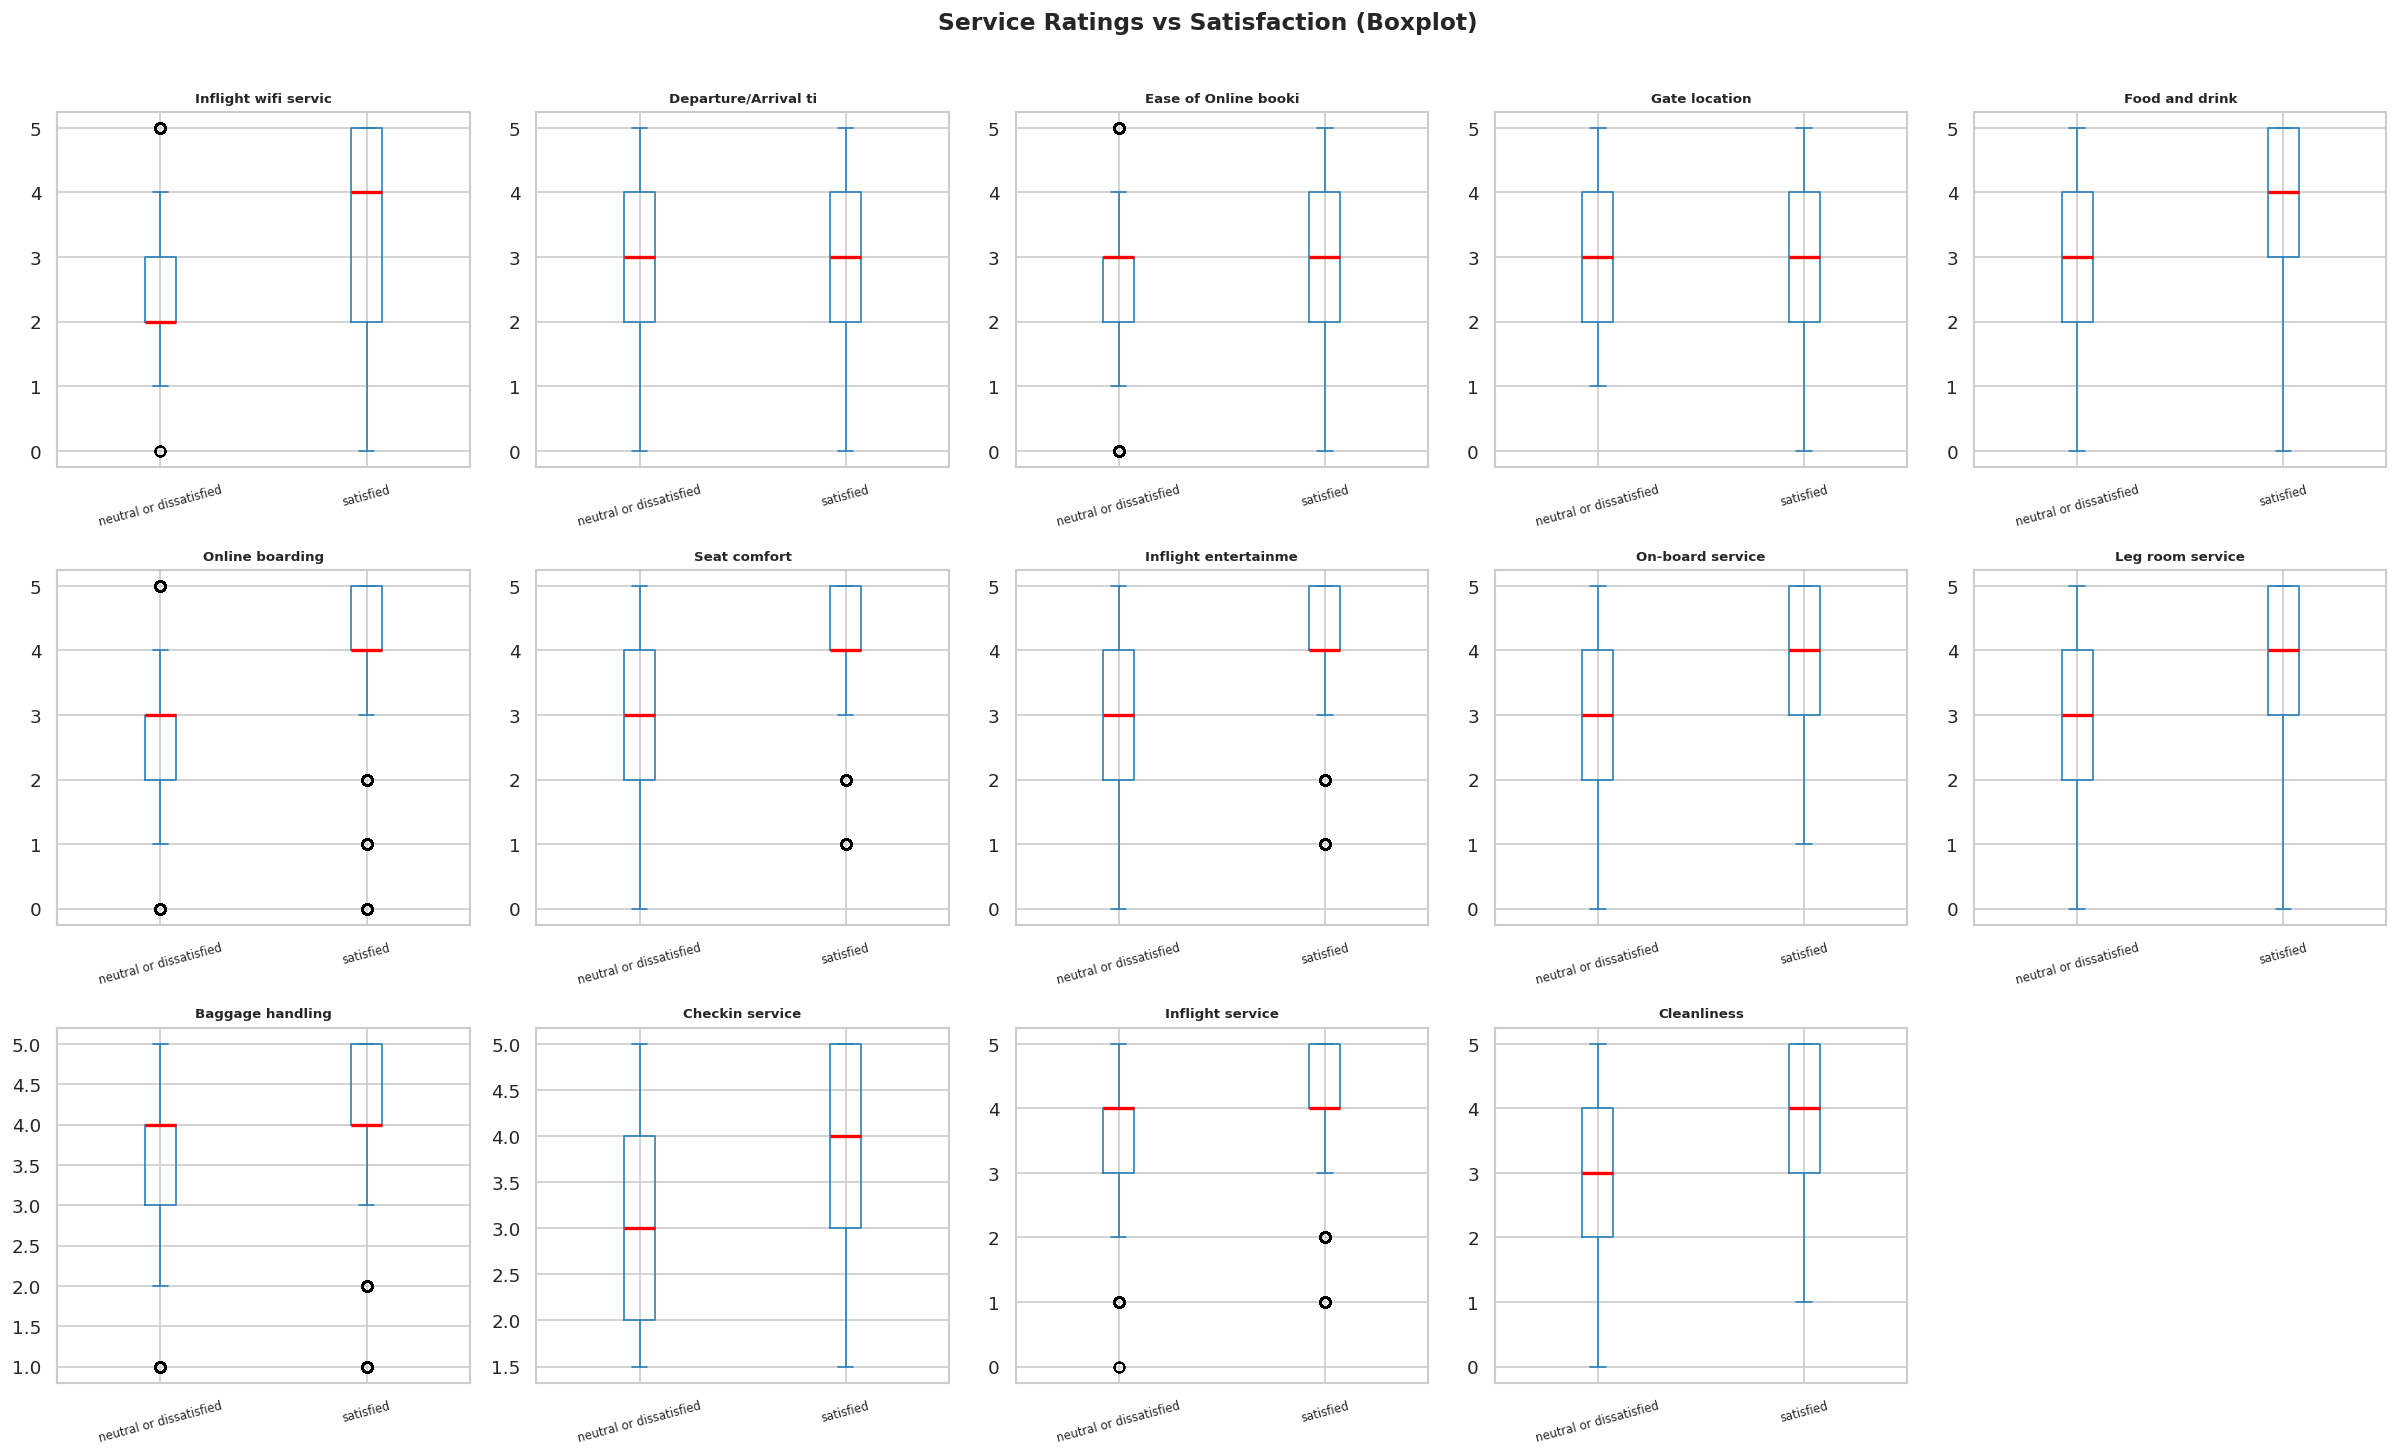

In [16]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(rating_cols):
    df.boxplot(column=col,
               by='satisfaction',
               ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red',
                                linewidth=2),
               whiskerprops=dict(color='#2980b9'),
               capprops=dict(color='#2980b9'))
    axes[i].set_title(col[:20],
                      fontweight='bold',
                      fontsize=8)
    axes[i].set_xlabel('')
    axes[i].tick_params(
        axis='x', rotation=15,
        labelsize=7)

for j in range(len(rating_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Service Ratings vs Satisfaction '
             '(Boxplot)',
             fontsize=14, fontweight='bold',
             y=1.01)
plt.tight_layout()
plt.savefig('LGBM_05_rating_boxplots.png',
            bbox_inches='tight')
plt.show()

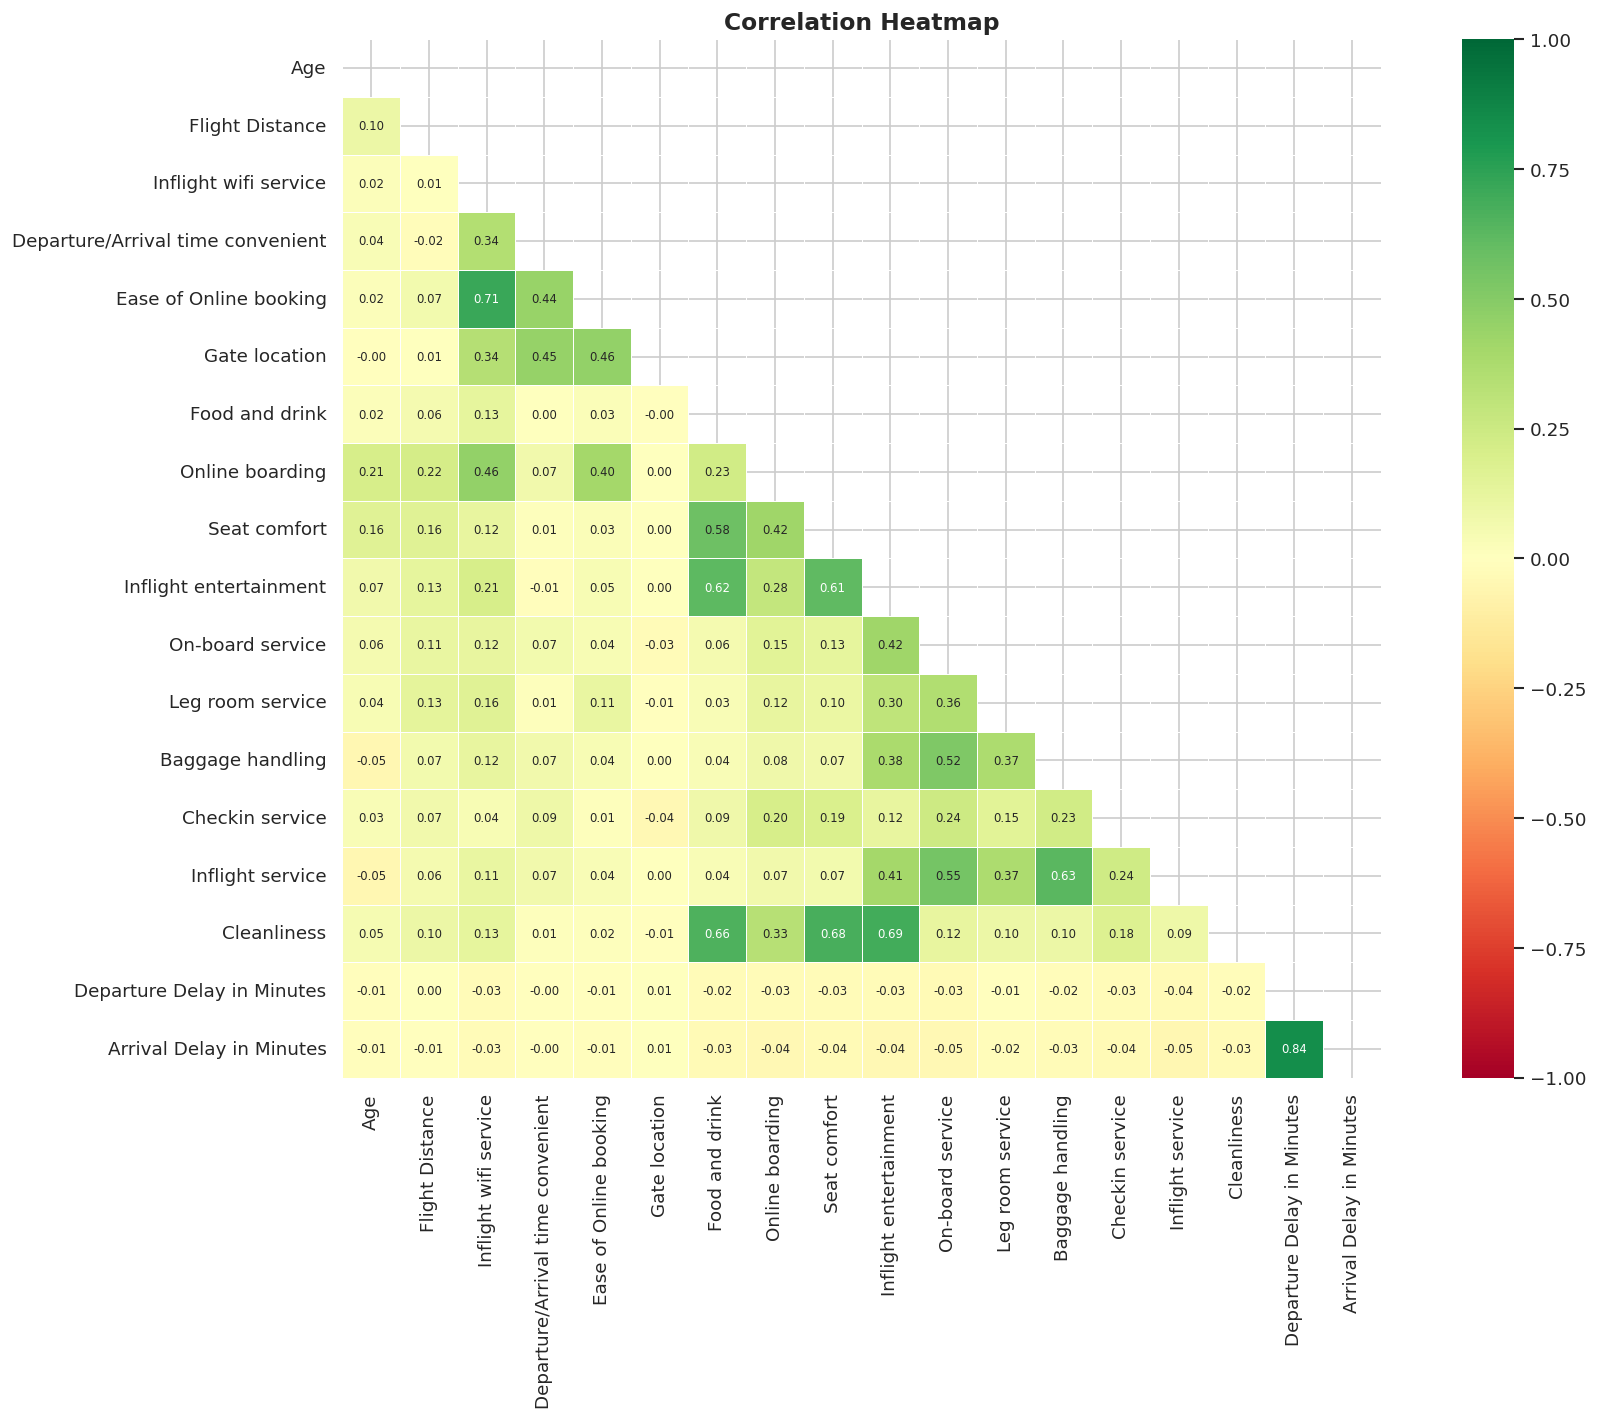

In [17]:
fig, ax = plt.subplots(figsize=(16, 12))

num_df = df.select_dtypes(include=[np.number])
corr   = num_df.corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.3, ax=ax,
            annot_kws={'fontsize': 7},
            vmin=-1, vmax=1,
            center=0, square=True)
ax.set_title('Correlation Heatmap',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('LGBM_06_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

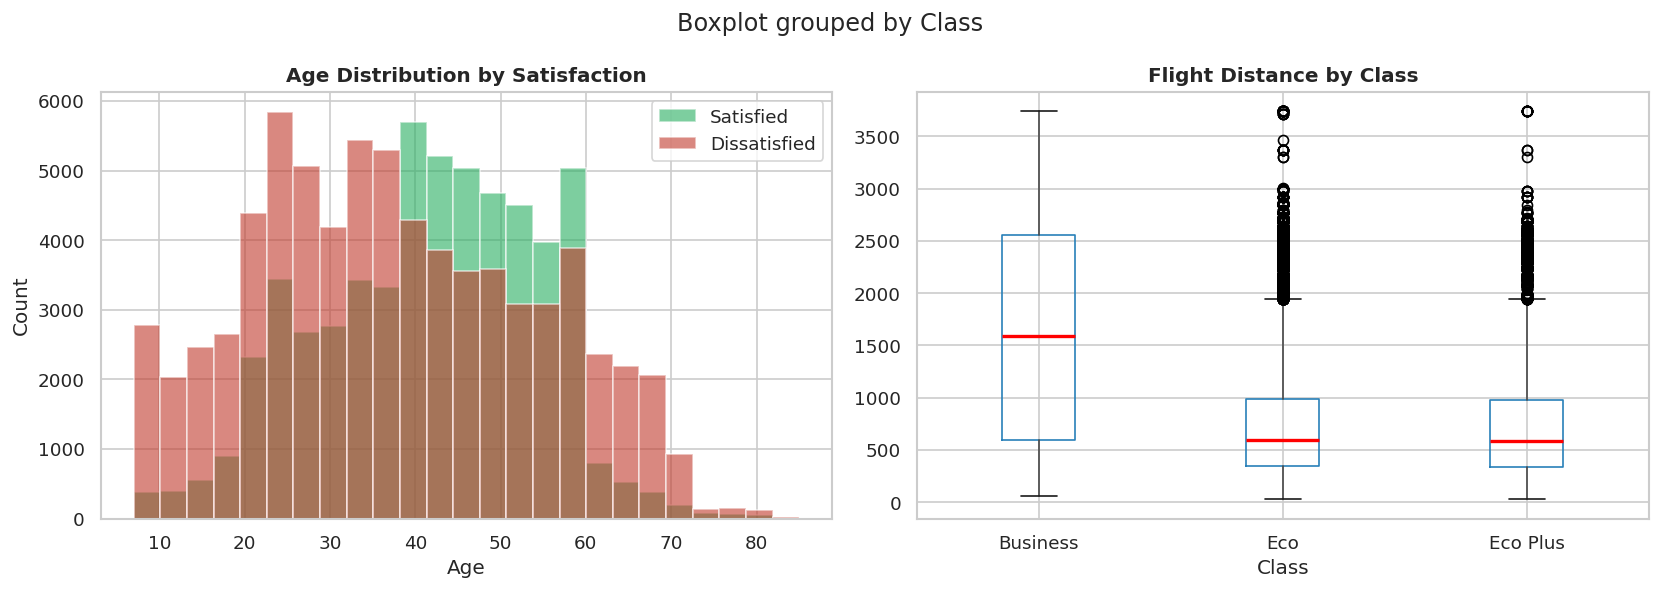

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by satisfaction
for label, color, name in zip(
        ['satisfied',
         'neutral or dissatisfied'],
        ['#27ae60', '#c0392b'],
        ['Satisfied', 'Dissatisfied']):
    axes[0].hist(
        df[df['satisfaction']==label]['Age'],
        bins=25, alpha=0.6,
        color=color, label=name)
axes[0].set_title('Age Distribution by Satisfaction',
                  fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Flight Distance by Class
if 'Class' in df.columns:
    df.boxplot(column='Flight Distance',
               by='Class', ax=axes[1],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red',
                                linewidth=2))
    axes[1].set_title(
        'Flight Distance by Class',
        fontweight='bold')
    axes[1].set_xlabel('Class')

plt.tight_layout()
plt.savefig('LGBM_07_age_distance.png',
            bbox_inches='tight')
plt.show()

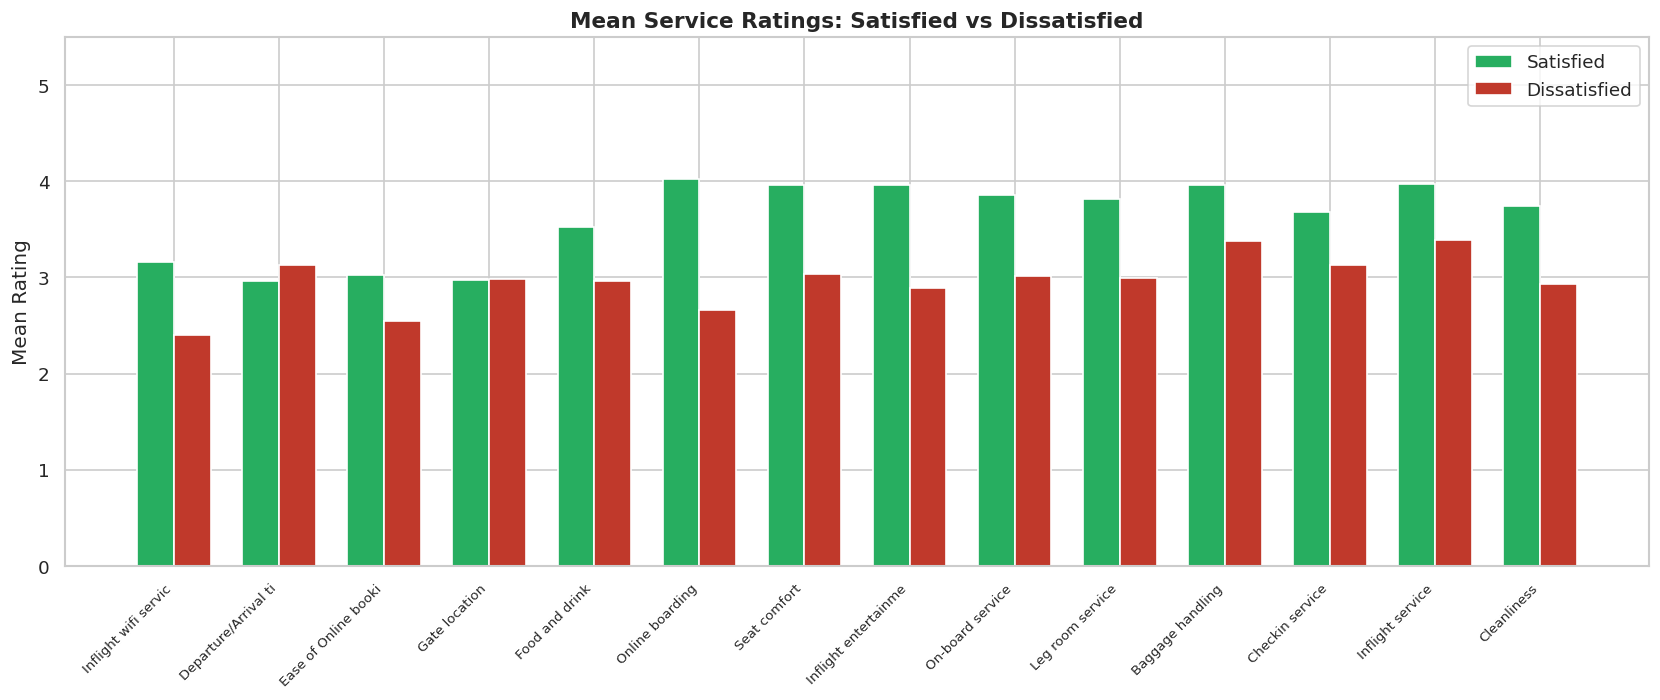

In [19]:
mean_ratings = df.groupby('satisfaction')[
    rating_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(rating_cols))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    mean_ratings.loc['satisfied'],
    width, label='Satisfied',
    color='#27ae60', edgecolor='white')
bars2 = ax.bar(
    x + width/2,
    mean_ratings.loc[
        'neutral or dissatisfied'],
    width, label='Dissatisfied',
    color='#c0392b', edgecolor='white')

ax.set_title('Mean Service Ratings: '
             'Satisfied vs Dissatisfied',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(
    [c[:20] for c in rating_cols],
    rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Rating')
ax.legend()
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.savefig('LGBM_08_mean_ratings.png',
            bbox_inches='tight')
plt.show()

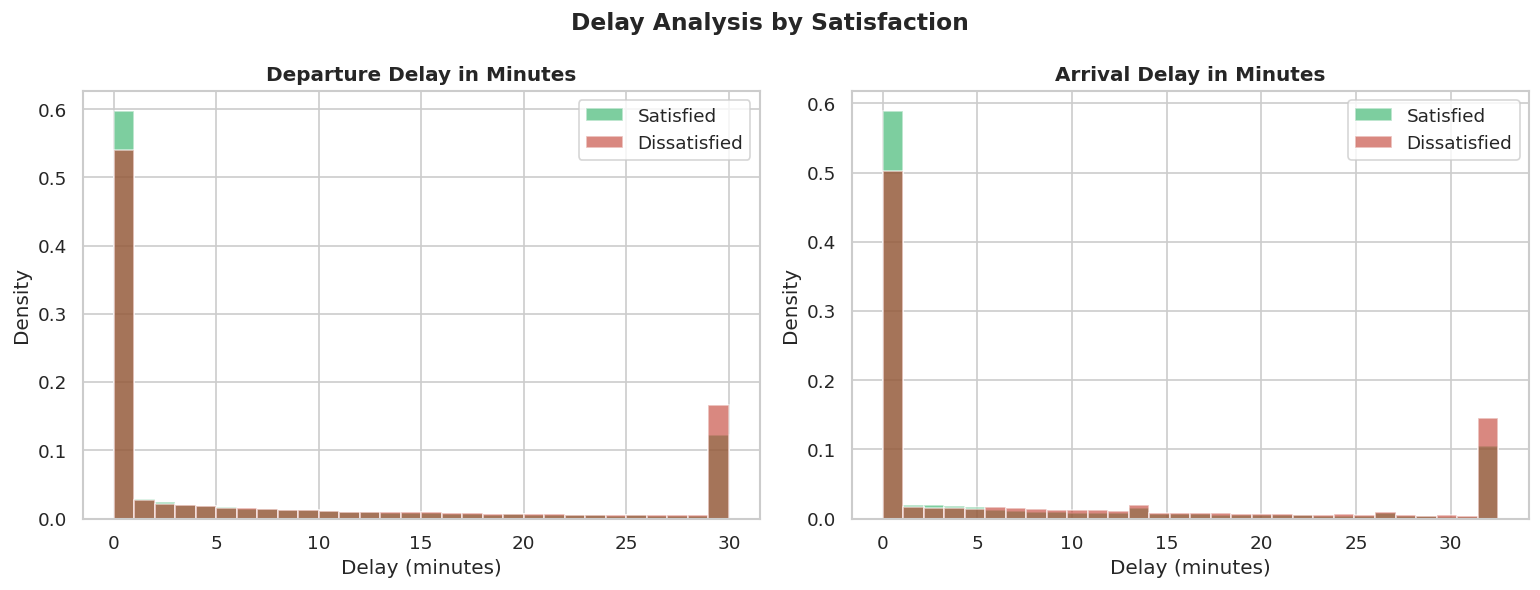

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

delay_cols = ['Departure Delay in Minutes',
              'Arrival Delay in Minutes']
delay_cols = [c for c in delay_cols
              if c in df.columns]

for i, col in enumerate(delay_cols):
    for label, color, name in zip(
            ['satisfied',
             'neutral or dissatisfied'],
            ['#27ae60', '#c0392b'],
            ['Satisfied', 'Dissatisfied']):
        axes[i].hist(
            df[df['satisfaction']==label][col],
            bins=30, alpha=0.6,
            color=color, label=name,
            density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Delay (minutes)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Delay Analysis by Satisfaction',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('LGBM_09_delay_analysis.png',
            bbox_inches='tight')
plt.show()

In [21]:
df_model = df.copy()

# ── 6.1 Encode Target
le_target = LabelEncoder()
df_model['satisfaction'] = le_target.fit_transform(
    df_model['satisfaction'])
# neutral or dissatisfied=0, satisfied=1
print("✅ Target encoded:")
for cls, enc in zip(
        le_target.classes_,
        le_target.transform(le_target.classes_)):
    print(f"   {cls} → {enc}")

# ── 6.2 Encode Categorical Features
# LightGBM can handle categoricals natively
# but we encode for sklearn compatibility

cat_feat_cols = df_model.select_dtypes(
    include='object').columns.tolist()
print(f"\n🔤 Encoding categoricals: {cat_feat_cols}")

le_dict = {}
for col in cat_feat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(
        df_model[col])
    le_dict[col] = le
    print(f"   ✅ {col}: "
          f"{dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── 6.3 Handle remaining nulls
df_model.fillna(
    df_model.median(numeric_only=True),
    inplace=True)

print(f"\n📐 Shape after encoding: {df_model.shape}")
df_model.head(3)

✅ Target encoded:
   neutral or dissatisfied → 0
   satisfied → 1

🔤 Encoding categoricals: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
   ✅ Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
   ✅ Customer Type: {'Loyal Customer': np.int64(0), 'disloyal Customer': np.int64(1)}
   ✅ Type of Travel: {'Business travel': np.int64(0), 'Personal Travel': np.int64(1)}
   ✅ Class: {'Business': np.int64(0), 'Eco': np.int64(1), 'Eco Plus': np.int64(2)}

📐 Shape after encoding: (129880, 23)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4.0,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1.5,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4.0,4,5,0,0.0,1


In [22]:
# Total service score
df_model['total_service_score'] = df_model[
    rating_cols].sum(axis=1)
print("✅ 'total_service_score' created")

# Average rating
df_model['avg_rating'] = df_model[
    rating_cols].mean(axis=1)
print("✅ 'avg_rating' created")

# Min rating (worst experience)
df_model['min_rating'] = df_model[
    rating_cols].min(axis=1)
print("✅ 'min_rating' created")

# Max rating (best experience)
df_model['max_rating'] = df_model[
    rating_cols].max(axis=1)
print("✅ 'max_rating' created")

# Rating std (consistency)
df_model['rating_std'] = df_model[
    rating_cols].std(axis=1)
print("✅ 'rating_std' created")

# Total delay
delay_c = [c for c in [
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes']
    if c in df_model.columns]
if delay_c:
    df_model['total_delay'] = df_model[
        delay_c].sum(axis=1)
    print("✅ 'total_delay' created")

# Has delay flag
if 'total_delay' in df_model.columns:
    df_model['has_delay'] = (
        df_model['total_delay'] > 0
    ).astype(int)
    print("✅ 'has_delay' created")

# Online experience score
online_cols = [c for c in [
    'Ease of Online booking',
    'Online boarding',
    'Inflight wifi service']
    if c in df_model.columns]
if online_cols:
    df_model['online_experience'] = df_model[
        online_cols].mean(axis=1)
    print("✅ 'online_experience' created")

# Comfort score
comfort_cols = [c for c in [
    'Seat comfort', 'Leg room service',
    'Cleanliness', 'Food and drink']
    if c in df_model.columns]
if comfort_cols:
    df_model['comfort_score'] = df_model[
        comfort_cols].mean(axis=1)
    print("✅ 'comfort_score' created")

# Service score
service_cols = [c for c in [
    'On-board service', 'Inflight service',
    'Baggage handling', 'Checkin service']
    if c in df_model.columns]
if service_cols:
    df_model['service_score'] = df_model[
        service_cols].mean(axis=1)
    print("✅ 'service_score' created")

print(f"\n📐 Final Shape: {df_model.shape}")

✅ 'total_service_score' created
✅ 'avg_rating' created
✅ 'min_rating' created
✅ 'max_rating' created
✅ 'rating_std' created
✅ 'total_delay' created
✅ 'has_delay' created
✅ 'online_experience' created
✅ 'comfort_score' created
✅ 'service_score' created

📐 Final Shape: (129880, 33)


In [23]:
X = df_model.drop(columns=['satisfaction'])
y = df_model['satisfaction']

print(f"🎯 Target distribution:")
print(f"   Dissatisfied (0): {(y==0).sum():,}")
print(f"   Satisfied (1)   : {(y==1).sum():,}")
print(f"   Satisfied Rate  : {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y)

# LightGBM does NOT require scaling
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Training set : {X_train.shape}")
print(f"✅ Test set     : {X_test.shape}")
print(f"✅ Features     : {X_train.shape[1]}")
print("\n📌 LightGBM does NOT need scaling!")

# LightGBM Dataset
lgb_train = lgb.Dataset(
    X_train, label=y_train)
lgb_test  = lgb.Dataset(
    X_test, label=y_test,
    reference=lgb_train)

feature_names = X.columns.tolist()
print(f"✅ LightGBM Dataset created!")

🎯 Target distribution:
   Dissatisfied (0): 73,452
   Satisfied (1)   : 56,428
   Satisfied Rate  : 43.4%

✅ Training set : (103904, 32)
✅ Test set     : (25976, 32)
✅ Features     : 32

📌 LightGBM does NOT need scaling!
✅ LightGBM Dataset created!


In [24]:
lgbm_baseline = LGBMClassifier(
    n_estimators  = 10,
    learning_rate = 0.1,
    max_depth     = -1,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = -1)

lgbm_baseline.fit(X_train, y_train)

y_pred_base = lgbm_baseline.predict(X_test)
y_prob_base = lgbm_baseline.predict_proba(
    X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, y_prob_base)
apr_base = average_precision_score(
    y_test, y_prob_base)

print(f"  Accuracy      : {acc_base*100:.2f}%")
print(f"  ROC-AUC       : {roc_base:.4f}")
print(f"  Avg Precision : {apr_base:.4f}")
print("\n🔧 Now let's tune with Native CV!")

  Accuracy      : 93.91%
  ROC-AUC       : 0.9812
  Avg Precision : 0.9783

🔧 Now let's tune with Native CV!


In [26]:
lgb_params = {
    'objective'       : 'binary',
    'metric'          : 'auc',
    'learning_rate'   : 0.05,
    'max_depth'       : -1,
    'num_leaves'      : 31,
    'min_child_samples': 20,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 0.1,
    'verbose'         : -1,
    'seed'            : 42
}

cv_results = lgb.cv(
    params            = lgb_params,
    train_set         = lgb_train,
    num_boost_round   = 500,
    nfold             = 5,
    stratified        = True,
    callbacks         = [
        lgb.early_stopping(50),
        lgb.log_evaluation(50)],
    seed              = 42)

best_rounds = len(cv_results['valid auc-mean'])
best_cv_auc = max(cv_results['valid auc-mean'])

print(f"\n✅ Best Rounds (CV) : {best_rounds}")
print(f"✅ Best AUC (CV)    : {best_cv_auc:.4f}")

Training until validation scores don't improve for 50 rounds
[50]	valid's auc: 0.99057 + 0.000423649
[100]	valid's auc: 0.993723 + 0.000207596
[150]	valid's auc: 0.994533 + 0.000187743
[200]	valid's auc: 0.994862 + 0.000179581
[250]	valid's auc: 0.995043 + 0.000209793
[300]	valid's auc: 0.995163 + 0.000185282
[350]	valid's auc: 0.995233 + 0.000196047
[400]	valid's auc: 0.995274 + 0.000197136
[450]	valid's auc: 0.995299 + 0.000173028
[500]	valid's auc: 0.995318 + 0.000169658
Did not meet early stopping. Best iteration is:
[500]	valid's auc: 0.995318 + 0.000169658

✅ Best Rounds (CV) : 500
✅ Best AUC (CV)    : 0.9953


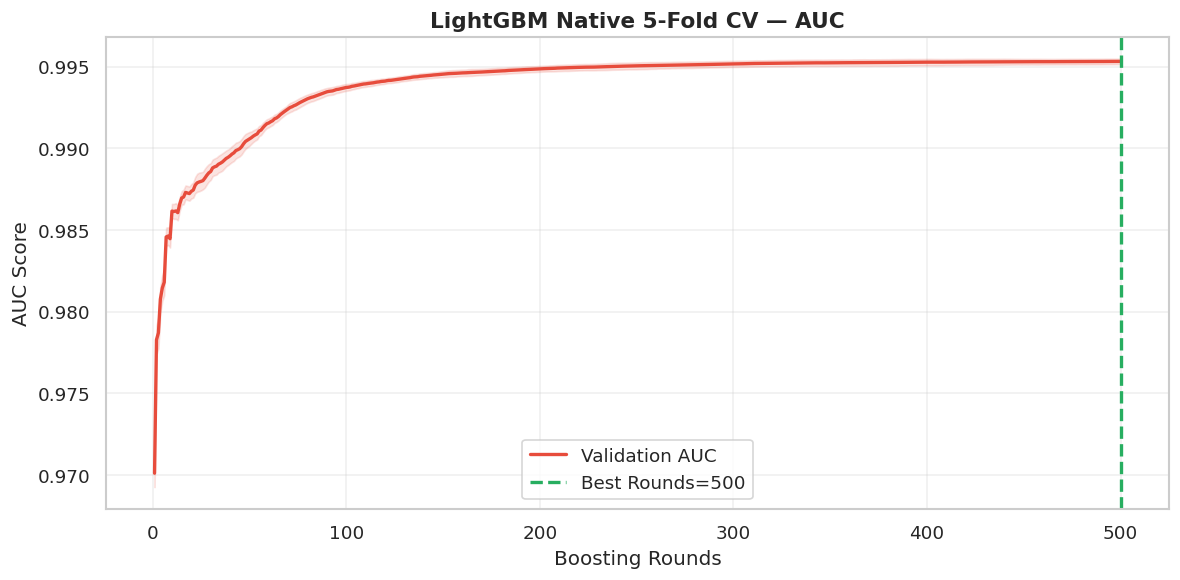

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

rounds = range(1, len(
    cv_results['valid auc-mean']) + 1)
cv_mean = np.array(cv_results['valid auc-mean'])
cv_std  = np.array(cv_results['valid auc-stdv'])

# Conditionally plot training AUC if keys exist
if 'train auc-mean' in cv_results and 'train auc-stdv' in cv_results:
    tr_mean = np.array(cv_results['train auc-mean'])
    tr_std  = np.array(cv_results['train auc-stdv'])

    ax.plot(rounds, tr_mean,
            color='#3498db', lw=2,
            label='Train AUC')
    ax.fill_between(rounds,
                    tr_mean - tr_std,
                    tr_mean + tr_std,
                    alpha=0.15, color='#3498db')
else:
    print("Warning: 'train auc-mean' or 'train auc-stdv' not found in cv_results. Skipping training AUC plot.")

ax.plot(rounds, cv_mean,
        color='#e74c3c', lw=2,
        label='Validation AUC')
ax.fill_between(rounds,
                cv_mean - cv_std,
                cv_mean + cv_std,
                alpha=0.15, color='#e74c3c')
ax.axvline(x=best_rounds,
           color='#27ae60',
           linestyle='--', lw=2,
           label=f'Best Rounds={best_rounds}')
ax.set_title('LightGBM Native 5-Fold CV — AUC',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Boosting Rounds')
ax.set_ylabel('AUC Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('LGBM_10_native_cv.png',
            bbox_inches='tight')
plt.show()

In [30]:
param_dist = {
    'n_estimators'      : [100, 200, 300],
    'learning_rate'     : [0.01, 0.05],
    'max_depth'         : [-1, 5, 7],
    'num_leaves'        : [15, 31, 50],
    'min_child_samples' : [5, 10, 20],
    'subsample'         : [0.6, 0.7, 0.8],
    'colsample_bytree'  : [0.6, 0.7, 0.8],
    'reg_alpha'         : [0, 0.01, 0.1],
    'reg_lambda'        : [0, 0.01, 0.1],
    'min_split_gain'    : [0, 0.01]
}

rand_search = RandomizedSearchCV(
    estimator = LGBMClassifier(
        random_state = 42,
        n_jobs       = -1,
        verbose      = -1),
    param_distributions = param_dist,
    n_iter       = 2,
    cv           = StratifiedKFold(2),
    scoring      = 'roc_auc',
    random_state = 42,
    n_jobs       = -1,
    verbose      = 1)

rand_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Random): "
      f"{rand_search.best_params_}")
print(f"✅ Best CV ROC-AUC     : "
      f"{rand_search.best_score_:.4f}")

Fitting 2 folds for each of 2 candidates, totalling 4 fits

✅ Best Params (Random): {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 200, 'min_split_gain': 0.01, 'min_child_samples': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
✅ Best CV ROC-AUC     : 0.9920


In [31]:
bp = rand_search.best_params_

param_grid = {
    'n_estimators': [bp['n_estimators']],
    'learning_rate': [
        bp['learning_rate'],
        min(1.0, bp['learning_rate'] + 0.02)
    ],
    'max_depth': [bp['max_depth']],
    'num_leaves': [bp['num_leaves']],
    'min_child_samples': [bp['min_child_samples']],
    'subsample': [bp['subsample']],
    'colsample_bytree': [bp['colsample_bytree']],
    'reg_alpha': [bp['reg_alpha']],
    'reg_lambda': [bp['reg_lambda']],
    'min_split_gain': [bp['min_split_gain']]
}

grid_search = GridSearchCV(
    estimator = LGBMClassifier(
        random_state = 42,
        n_jobs       = -1,
        verbose      = -1),
    param_grid   = param_grid,
    cv           = StratifiedKFold(5),
    scoring      = 'roc_auc',
    n_jobs       = -1,
    verbose      = 1)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Grid): "
      f"{grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC   : "
      f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 2 candidates, totalling 10 fits

✅ Best Params (Grid): {'colsample_bytree': 0.8, 'learning_rate': 0.07, 'max_depth': 5, 'min_child_samples': 5, 'min_split_gain': 0.01, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8}
✅ Best CV ROC-AUC   : 0.9933


In [37]:
lgbm_best = grid_search.best_estimator_
lgbm_best.fit(
    X_train, y_train,
    eval_set        = [(X_train, y_train),
                       (X_test,  y_test)],
    eval_metric     = 'auc',
    callbacks       = [
        lgb.early_stopping(50),
        lgb.log_evaluation(0)])

y_pred      = lgbm_best.predict(X_test)
y_pred_prob = lgbm_best.predict_proba(
    X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)
apr = average_precision_score(
    y_test, y_pred_prob)
cv  = cross_val_score(
    lgbm_best, X_train, y_train,
    cv      = StratifiedKFold(5),
    scoring = 'roc_auc')

print(f"\n{'Metric':<30} "
      f"{'Baseline':>10} {'Tuned':>10}")
print("-" * 52)
print(f"{'Accuracy':<30} "
      f"{acc_base*100:>9.2f}% "
      f"{acc*100:>9.2f}%")
print(f"{'ROC-AUC':<30} "
      f"{roc_base:>10.4f} {roc:>10.4f}")
print(f"{'Avg Precision (PR-AUC)':<30} "
      f"{apr_base:>10.4f} {apr:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<30} "
      f"{'—':>10} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<30} "
      f"{'—':>10} {cv.std():>10.4f}")

print(f"\n📋 Classification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Dissatisfied',
                  'Satisfied']))

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[200]	training's auc: 0.993992	training's binary_logloss: 0.0997078	valid_1's auc: 0.992956	valid_1's binary_logloss: 0.105921

Metric                           Baseline      Tuned
----------------------------------------------------
Accuracy                           93.91%     95.65%
ROC-AUC                            0.9812     0.9930
Avg Precision (PR-AUC)             0.9783     0.9917
CV ROC-AUC (mean)                       —     0.9933
CV ROC-AUC (std)                        —     0.0005

📋 Classification Report:

              precision    recall  f1-score   support

Dissatisfied       0.95      0.98      0.96     14690
   Satisfied       0.97      0.93      0.95     11286

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.96     25976
weighted avg       0.96      0.96      0.96     25976



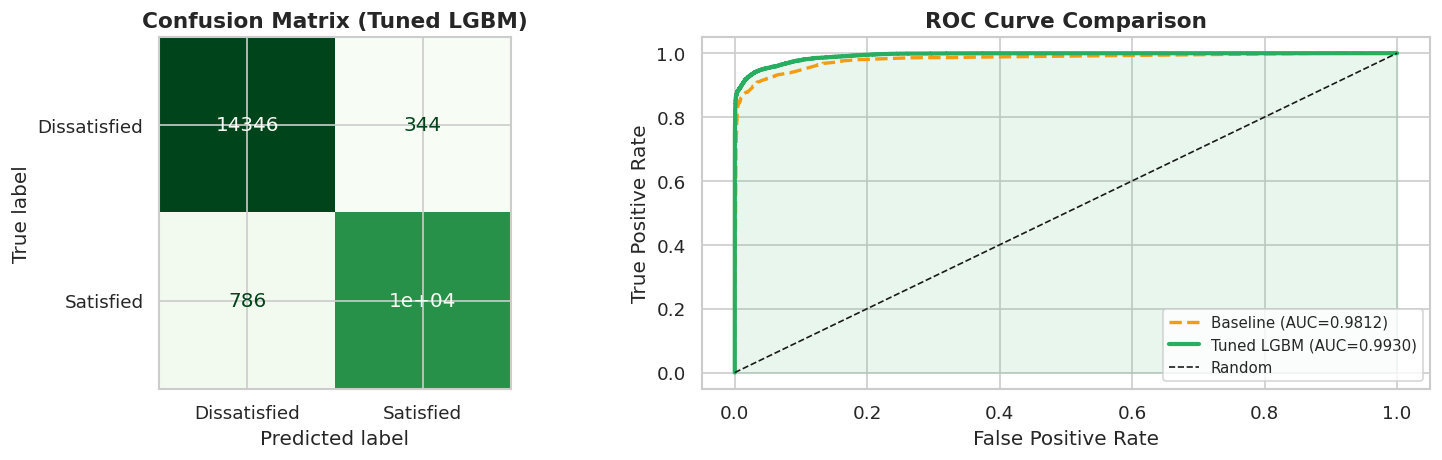

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Dissatisfied',
                        'Satisfied'])
disp.plot(ax=axes[0], colorbar=False,
          cmap='Greens')
axes[0].set_title('Confusion Matrix (Tuned LGBM)',
                  fontsize=13, fontweight='bold')

fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_prob)

axes[1].plot(fpr_b, tpr_b,
             color='#f39c12', lw=2,
             linestyle='--',
             label=f'Baseline '
                   f'(AUC={roc_base:.4f})')
axes[1].plot(fpr_t, tpr_t,
             color='#27ae60', lw=2.5,
             label=f'Tuned LGBM '
                   f'(AUC={roc:.4f})')
axes[1].fill_between(fpr_t, tpr_t,
                     alpha=0.1,
                     color='#27ae60')
axes[1].plot([0,1],[0,1], 'k--',
             lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('LGBM_11_confusion_roc.png',
            bbox_inches='tight')
plt.show()

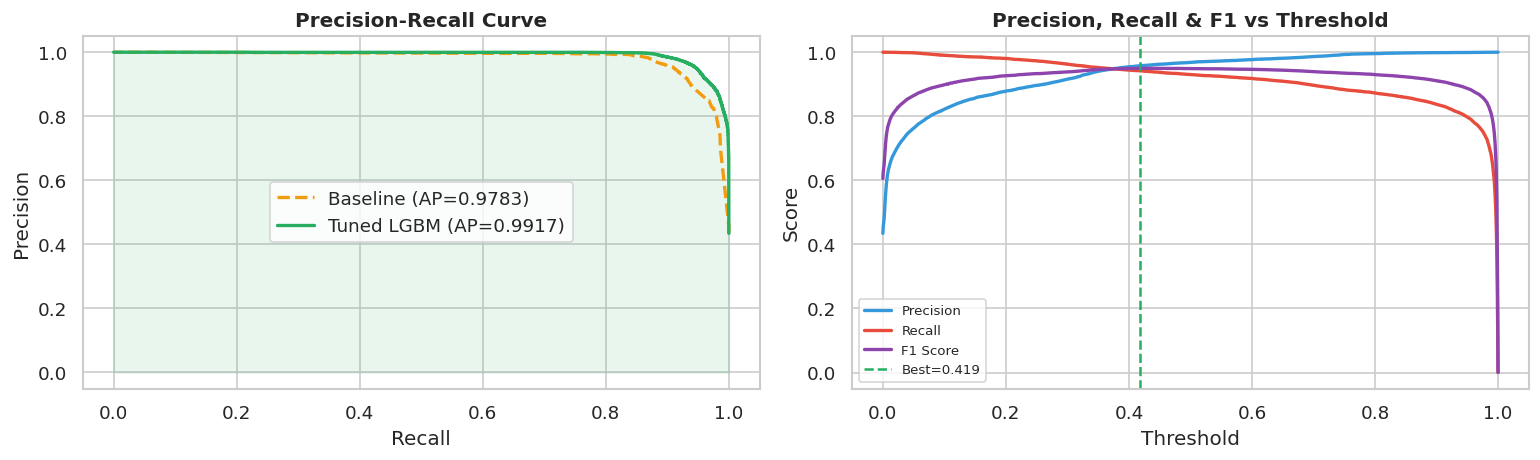

In [34]:
precision, recall, thresholds = \
    precision_recall_curve(y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pr_b, rc_b, _ = precision_recall_curve(
    y_test, y_prob_base)
axes[0].plot(rc_b, pr_b,
             color='#f39c12', lw=2,
             linestyle='--',
             label=f'Baseline '
                   f'(AP={apr_base:.4f})')
axes[0].plot(recall, precision,
             color='#27ae60', lw=2,
             label=f'Tuned LGBM '
                   f'(AP={apr:.4f})')
axes[0].fill_between(recall, precision,
                     alpha=0.1,
                     color='#27ae60')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve',
                  fontsize=12, fontweight='bold')
axes[0].legend()

f1 = (2 * precision[:-1] * recall[:-1] /
      (precision[:-1] + recall[:-1] + 1e-8))
best_thresh = thresholds[np.argmax(f1)]

axes[1].plot(thresholds, precision[:-1],
             color='#3498db', lw=2,
             label='Precision')
axes[1].plot(thresholds, recall[:-1],
             color='#e74c3c', lw=2,
             label='Recall')
axes[1].plot(thresholds, f1,
             color='#8e44ad', lw=2,
             label='F1 Score')
axes[1].axvline(x=best_thresh,
                color='#27ae60',
                linestyle='--',
                label=f'Best='
                      f'{best_thresh:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall & F1 '
                  'vs Threshold',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('LGBM_12_precision_recall.png',
            bbox_inches='tight')
plt.show()

⏳ Calculating Permutation Importance...


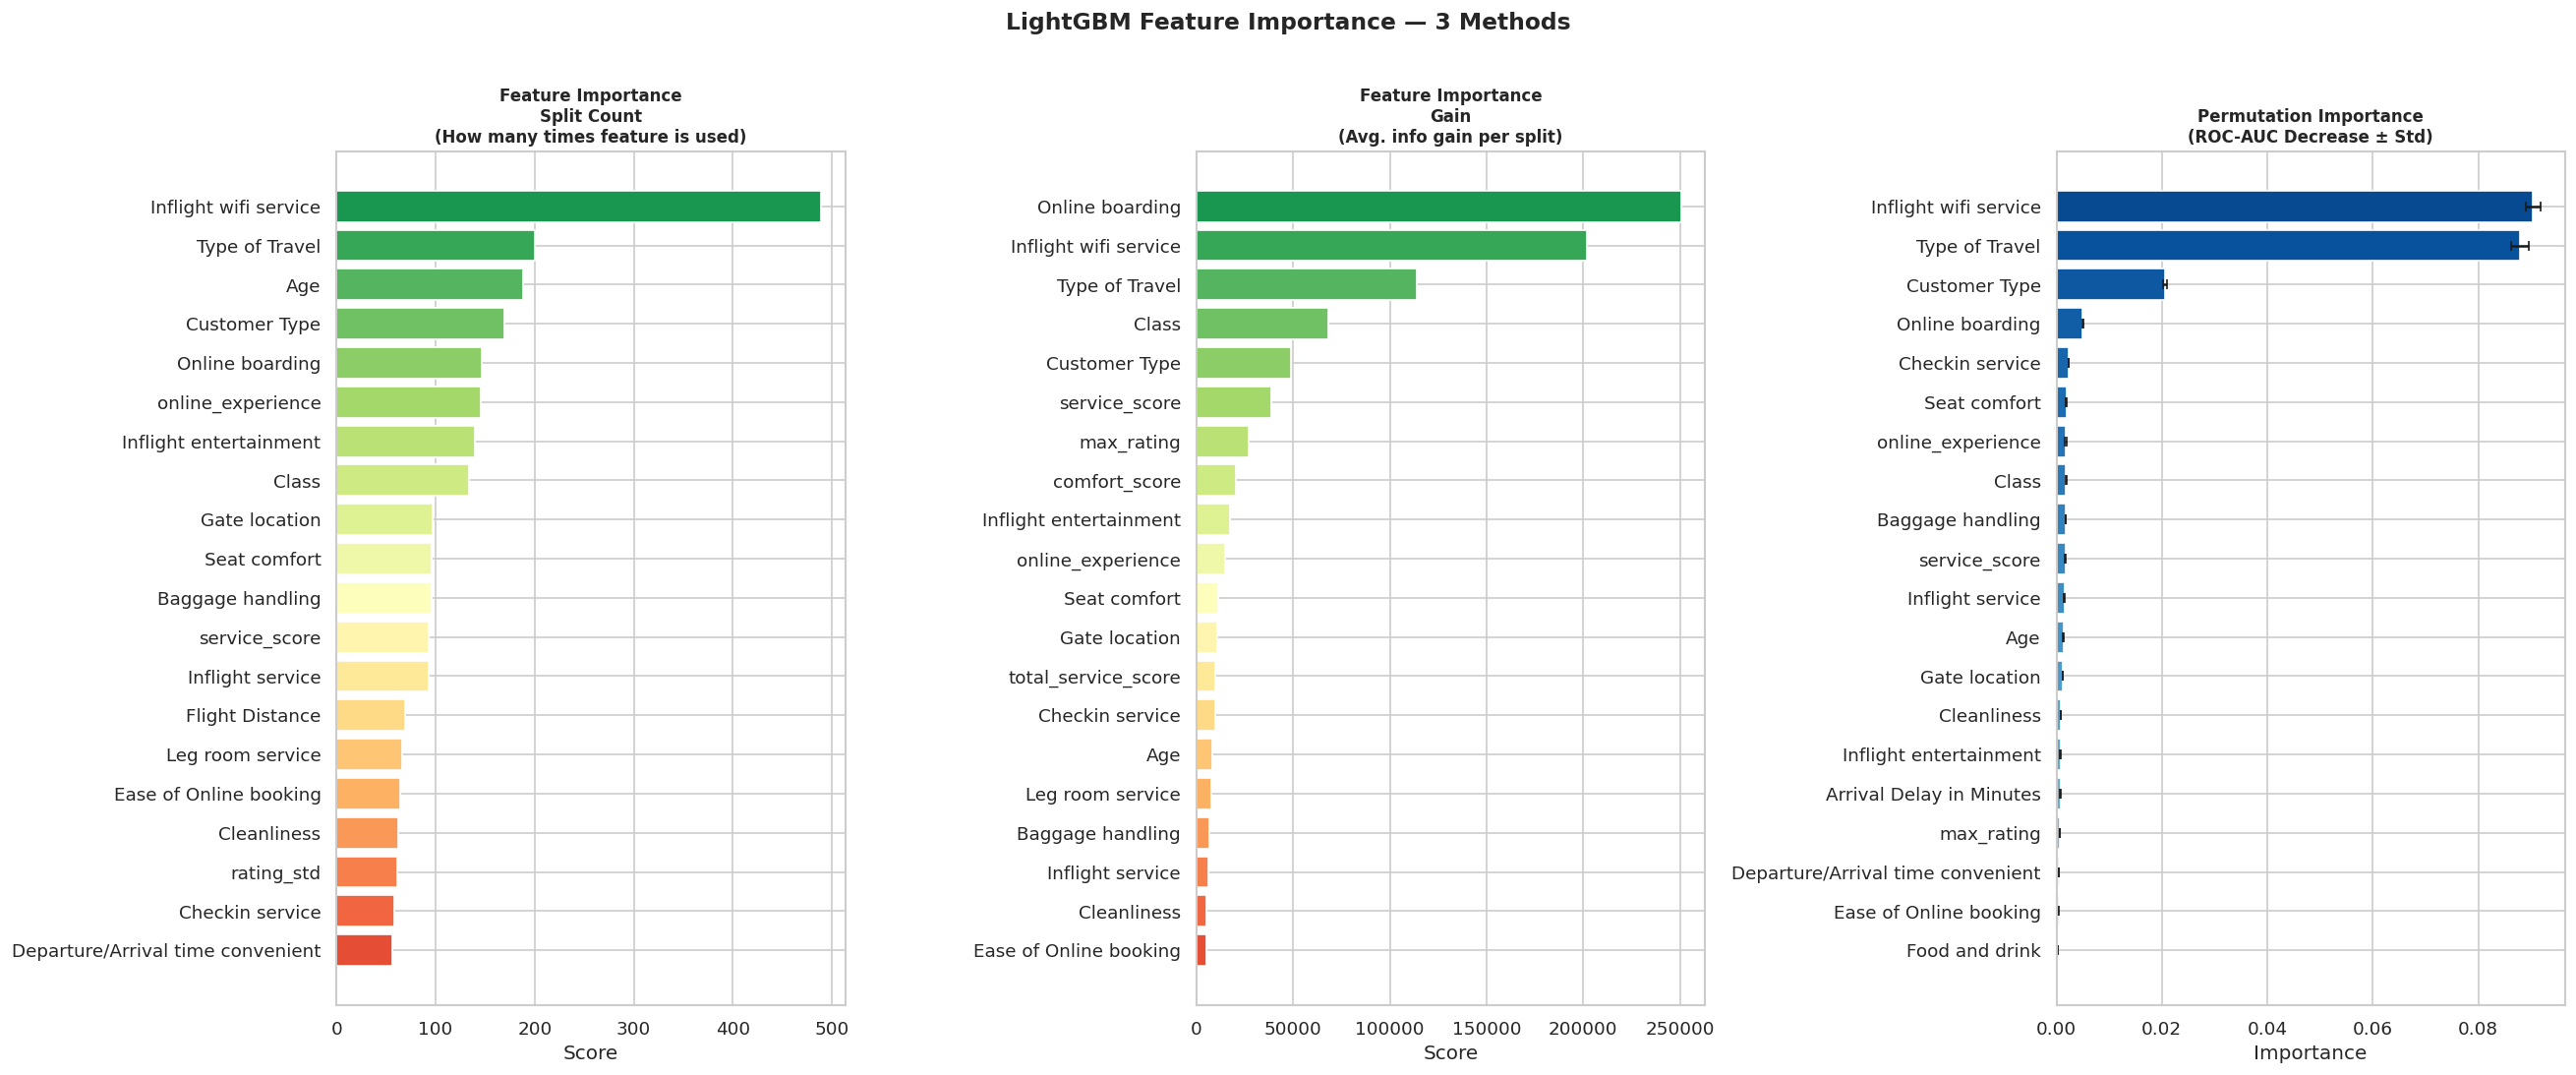

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(22, 9))

imp_types  = ['split', 'gain']
imp_titles = [
    'Split Count\n(How many times feature is used)',
    'Gain\n(Avg. info gain per split)']

for ax, imp_type, title in zip(
        axes[:2], imp_types, imp_titles):
    importances = lgbm_best.booster_.feature_importance(
        importance_type=imp_type)
    fi_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': importances
    }).sort_values('Importance',
                   ascending=False).head(20)

    colors = plt.cm.RdYlGn(
        np.linspace(0.15, 0.9,
                    len(fi_df)))[::-1]
    ax.barh(fi_df['Feature'],
            fi_df['Importance'],
            color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance\n{title}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Score')
    ax.invert_yaxis()

# Permutation Importance
print("⏳ Calculating Permutation Importance...")
perm_imp = permutation_importance(
    lgbm_best, X_test, y_test,
    n_repeats    = 10,
    random_state = 42,
    scoring      = 'roc_auc',
    n_jobs       = -1)

perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance',
               ascending=False).head(20)

colors_p = plt.cm.Blues(
    np.linspace(0.4, 0.9,
                len(perm_df)))[::-1]
axes[2].barh(perm_df['Feature'],
             perm_df['Importance'],
             xerr=perm_df['Std'],
             color=colors_p,
             edgecolor='white', capsize=3)
axes[2].set_title('Permutation Importance\n'
                  '(ROC-AUC Decrease ± Std)',
                  fontweight='bold', fontsize=10)
axes[2].set_xlabel('Importance')
axes[2].axvline(x=0, color='red',
                linestyle='--', lw=1)
axes[2].invert_yaxis()

plt.suptitle('LightGBM Feature Importance '
             '— 3 Methods',
             fontsize=14, fontweight='bold',
             y=1.01)
plt.tight_layout()
plt.savefig('LGBM_13_feature_importance.png',
            bbox_inches='tight')
plt.show()

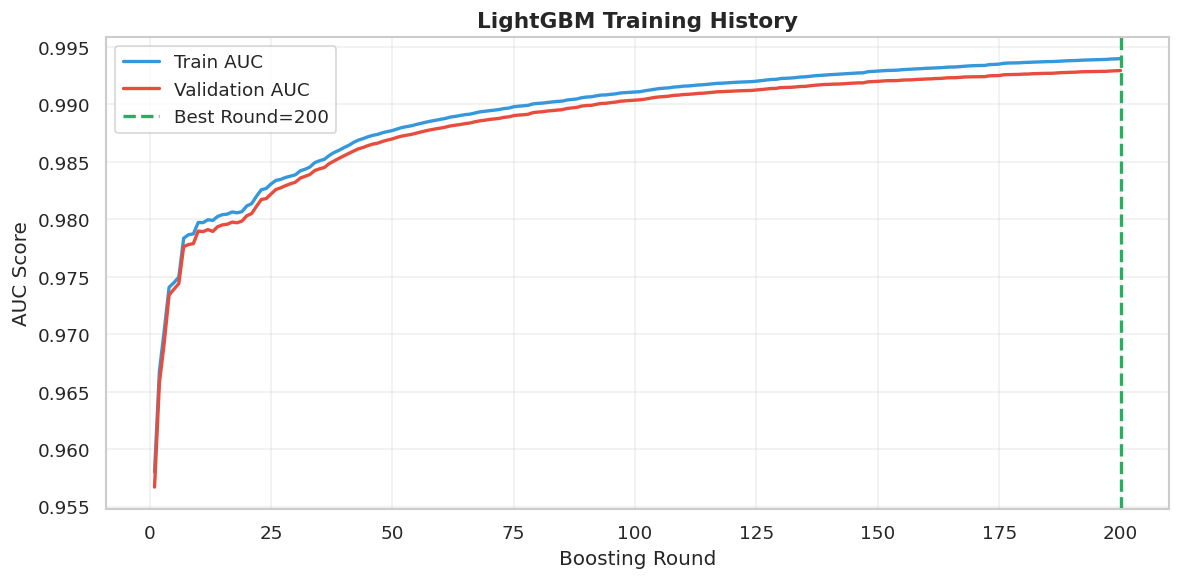

In [38]:
evals_result = lgbm_best.evals_result_

fig, ax = plt.subplots(figsize=(10, 5))

train_auc = evals_result['training']['auc']
valid_auc = evals_result['valid_1']['auc']
rounds    = range(1, len(train_auc) + 1)

ax.plot(rounds, train_auc,
        color='#3498db', lw=2,
        label='Train AUC')
ax.plot(rounds, valid_auc,
        color='#e74c3c', lw=2,
        label='Validation AUC')
ax.axvline(
    x=np.argmax(valid_auc) + 1,
    color='#27ae60',
    linestyle='--', lw=2,
    label=f'Best Round='
          f'{np.argmax(valid_auc)+1}')
ax.set_title('LightGBM Training History',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUC Score')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('LGBM_14_training_history.png',
            bbox_inches='tight')
plt.show()

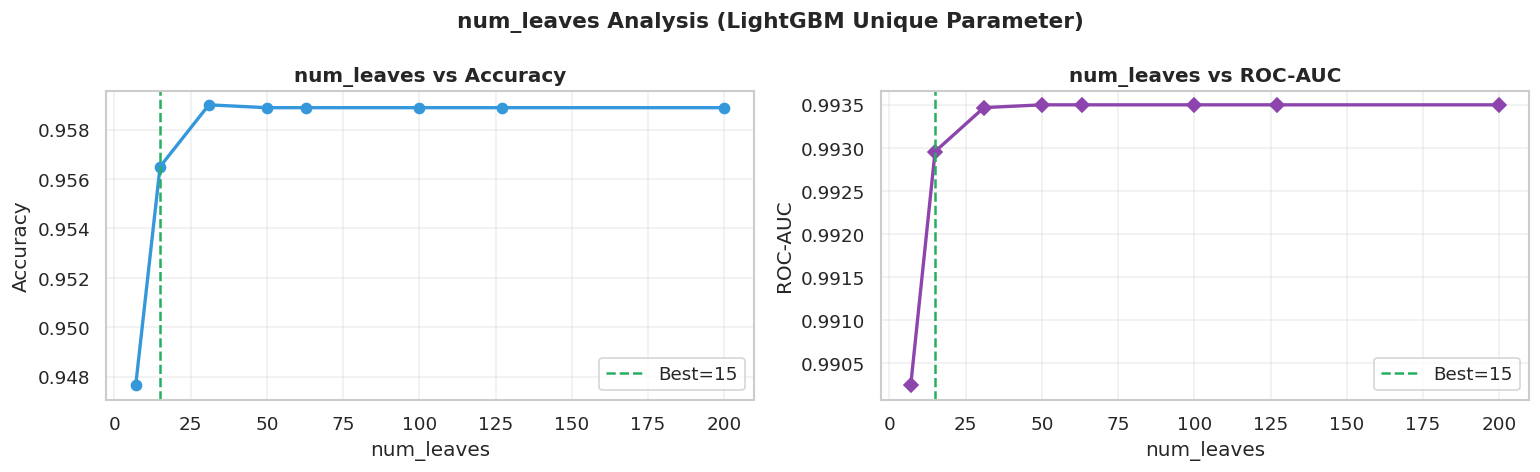

In [40]:
leaves_range = [7, 15, 31, 50,
                63, 100, 127, 200]
leaves_acc   = []
leaves_roc   = []

for nl in leaves_range:
    # Create a copy of best_params_ and remove 'num_leaves' from it
    params_without_nl = {k: v for k, v in grid_search.best_params_.items() if k != 'num_leaves'}
    m = LGBMClassifier(
        **params_without_nl,
        num_leaves   = nl,
        random_state = 42,
        n_jobs       = -1,
        verbose      = -1)
    m.fit(X_train, y_train)
    leaves_acc.append(
        accuracy_score(y_test,
                       m.predict(X_test)))
    leaves_roc.append(
        roc_auc_score(
            y_test,
            m.predict_proba(X_test)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(leaves_range, leaves_acc,
             'o-', color='#3498db', lw=2)
axes[0].axvline(
    x=grid_search.best_params_['num_leaves'],
    color='#27ae60', linestyle='--',
    label=f'Best='
          f'{grid_search.best_params_["num_leaves"]}')
axes[0].set_title('num_leaves vs Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('num_leaves')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(leaves_range, leaves_roc,
             'D-', color='#8e44ad', lw=2)
axes[1].axvline(
    x=grid_search.best_params_['num_leaves'],
    color='#27ae60', linestyle='--',
    label=f'Best='
          f'{grid_search.best_params_["num_leaves"]}')
axes[1].set_title('num_leaves vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('num_leaves')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('num_leaves Analysis '
             '(LightGBM Unique Parameter)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('LGBM_15_num_leaves.png',
            bbox_inches='tight')
plt.show()

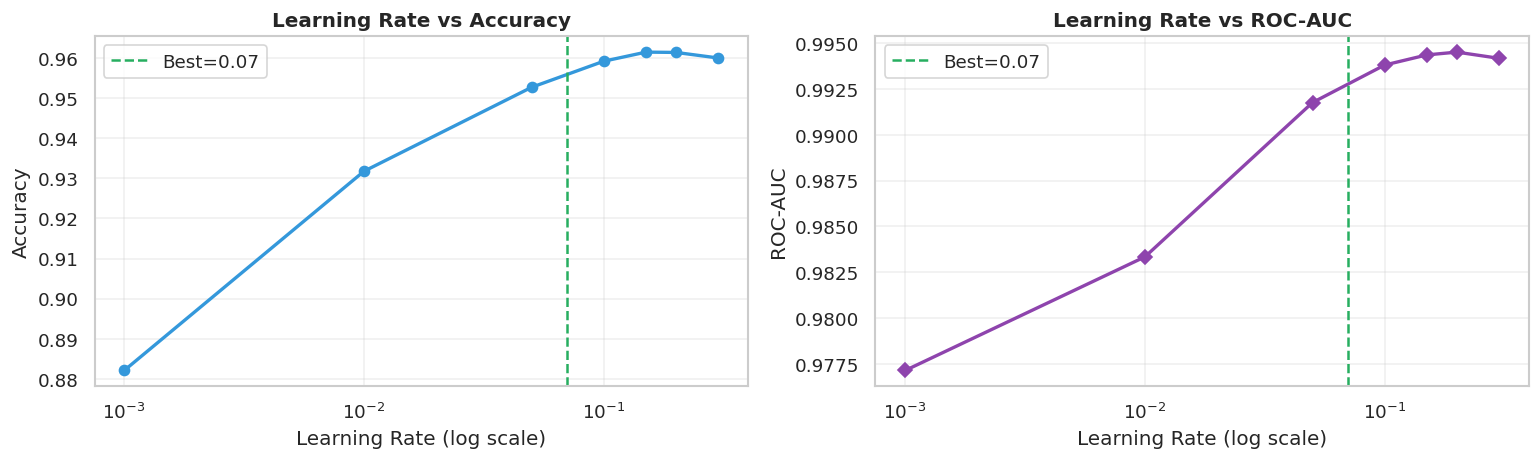

In [42]:
lr_values = [0.001, 0.01, 0.05,
              0.1, 0.15, 0.2, 0.3]
lr_acc    = []
lr_roc    = []

for lr in lr_values:
    # Create a copy of best_params_ and remove 'learning_rate' from it
    params_without_lr = {k: v for k, v in grid_search.best_params_.items() if k != 'learning_rate'}
    m = LGBMClassifier(
        **params_without_lr,
        learning_rate = lr,
        random_state  = 42,
        n_jobs        = -1,
        verbose       = -1)
    m.fit(X_train, y_train)
    lr_acc.append(
        accuracy_score(y_test,
                       m.predict(X_test)))
    lr_roc.append(
        roc_auc_score(
            y_test,
            m.predict_proba(X_test)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(lr_values, lr_acc,
                 'o-', color='#3498db', lw=2)
axes[0].axvline(
    x=grid_search.best_params_['learning_rate'],
    color='#27ae60', linestyle='--',
    label=f'Best='
          f'{grid_search.best_params_["learning_rate"]}')
axes[0].set_title('Learning Rate vs Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Learning Rate (log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(lr_values, lr_roc,
                 'D-', color='#8e44ad', lw=2)
axes[1].axvline(
    x=grid_search.best_params_['learning_rate'],
    color='#27ae60', linestyle='--',
    label=f'Best='
          f'{grid_search.best_params_["learning_rate"]}')
axes[1].set_title('Learning Rate vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('LGBM_16_learning_rate.png',
            bbox_inches='tight')
plt.show()

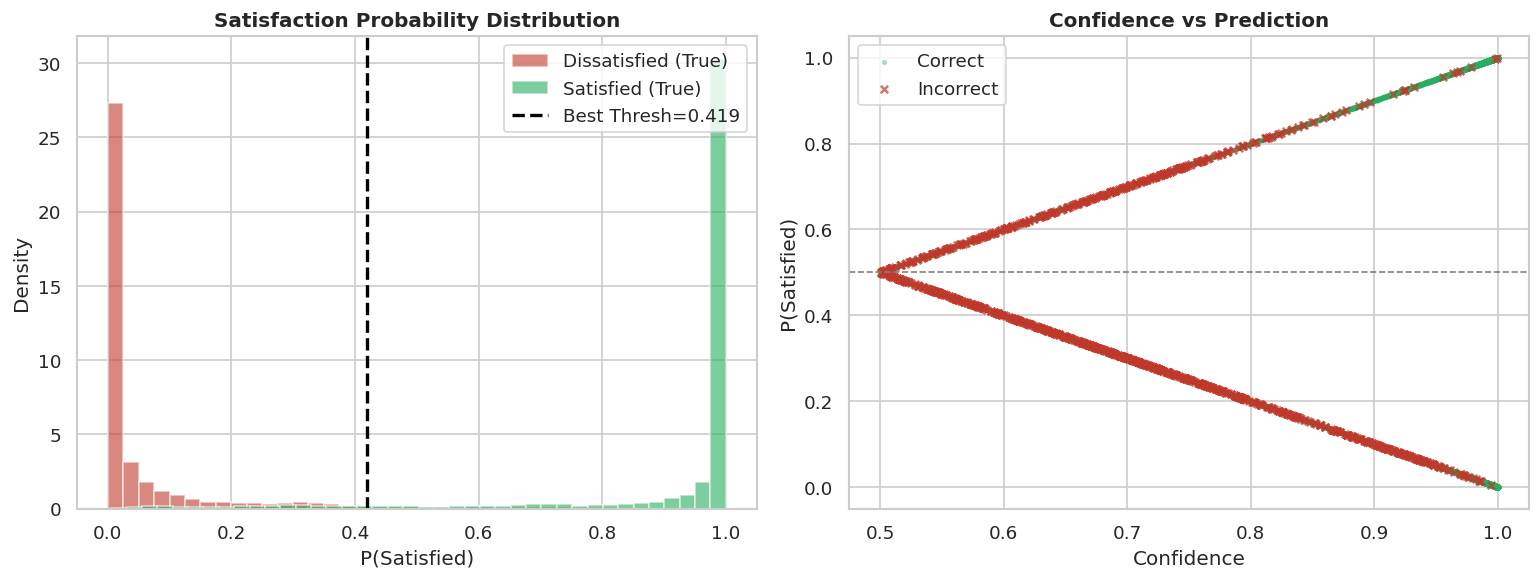

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    y_pred_prob[y_test == 0],
    bins=40, alpha=0.6,
    color='#c0392b',
    label='Dissatisfied (True)',
    density=True)
axes[0].hist(
    y_pred_prob[y_test == 1],
    bins=40, alpha=0.6,
    color='#27ae60',
    label='Satisfied (True)',
    density=True)
axes[0].axvline(x=best_thresh,
                color='black',
                linestyle='--', lw=2,
                label=f'Best Thresh='
                      f'{best_thresh:.3f}')
axes[0].set_title('Satisfaction Probability '
                  'Distribution',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(Satisfied)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Confidence Analysis
confidence   = np.maximum(
    y_pred_prob, 1 - y_pred_prob)
correct_mask = (y_pred == y_test.values)

axes[1].scatter(
    confidence[correct_mask],
    y_pred_prob[correct_mask],
    alpha=0.3, s=5,
    color='#27ae60',
    label='Correct')
axes[1].scatter(
    confidence[~correct_mask],
    y_pred_prob[~correct_mask],
    alpha=0.7, s=20,
    color='#c0392b',
    label='Incorrect', marker='x')
axes[1].axhline(y=0.5, color='gray',
                linestyle='--', lw=1)
axes[1].set_title('Confidence vs Prediction',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('P(Satisfied)')
axes[1].legend()

plt.tight_layout()
plt.savefig('LGBM_17_prob_distribution.png',
            bbox_inches='tight')
plt.show()

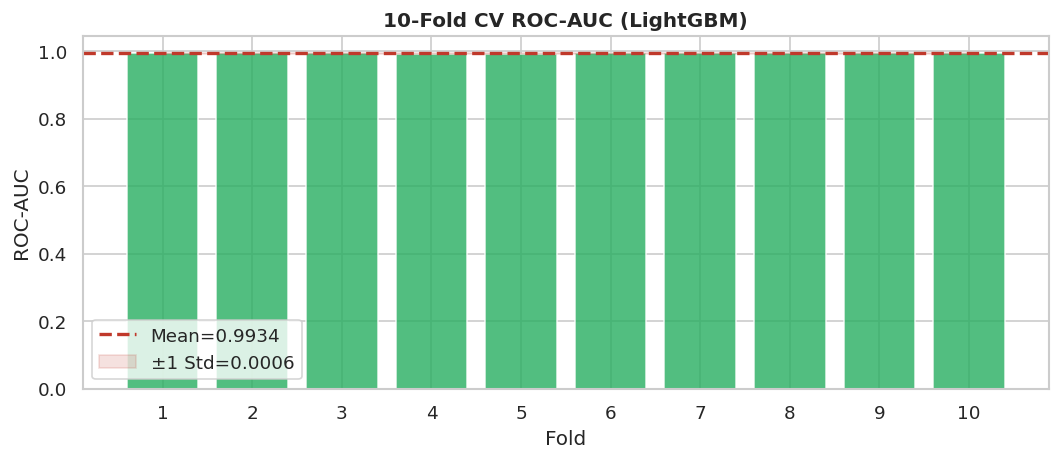

In [44]:
cv_scores_10 = cross_val_score(
    lgbm_best, X_train, y_train,
    cv=StratifiedKFold(10),
    scoring='roc_auc')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores_10,
       color='#27ae60',
       edgecolor='white', alpha=0.8)
ax.axhline(y=cv_scores_10.mean(),
           color='#c0392b',
           linestyle='--', lw=2,
           label=f'Mean='
                 f'{cv_scores_10.mean():.4f}')
ax.fill_between(
    range(1, 11),
    cv_scores_10.mean() - cv_scores_10.std(),
    cv_scores_10.mean() + cv_scores_10.std(),
    alpha=0.15, color='#c0392b',
    label=f'±1 Std='
          f'{cv_scores_10.std():.4f}')
ax.set_title('10-Fold CV ROC-AUC (LightGBM)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('LGBM_18_cv_scores.png',
            bbox_inches='tight')
plt.show()

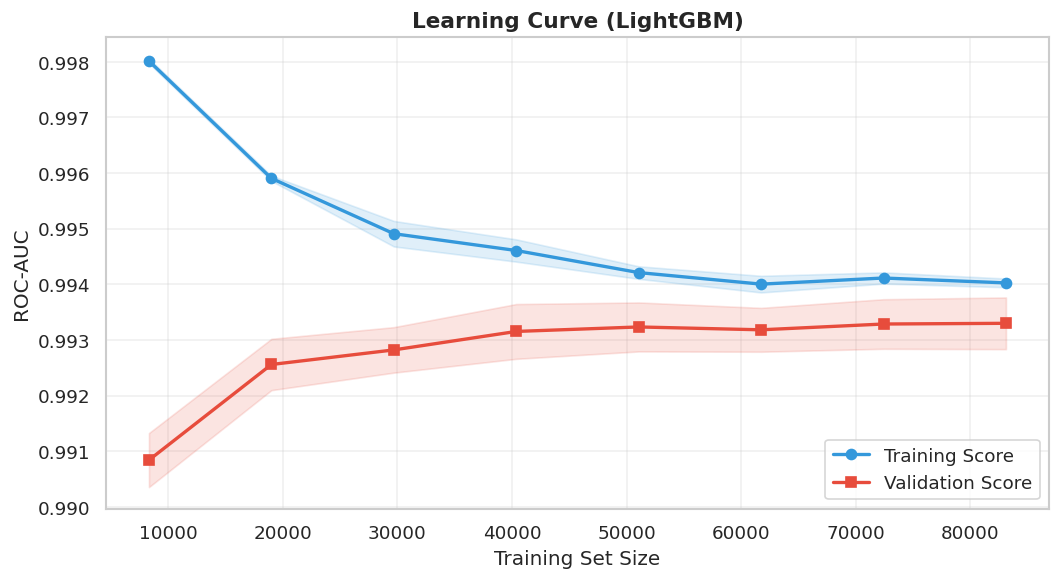

In [45]:
train_sizes, train_sc, val_sc = learning_curve(
    lgbm_best, X_train, y_train,
    train_sizes = np.linspace(0.1, 1.0, 8),
    cv          = StratifiedKFold(5),
    scoring     = 'roc_auc',
    n_jobs      = -1)

train_mean = train_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_mean   = val_sc.mean(axis=1)
val_std    = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean,
        'o-', color='#3498db', lw=2,
        label='Training Score')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean,
        's-', color='#e74c3c', lw=2,
        label='Validation Score')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15, color='#e74c3c')
ax.set_title('Learning Curve (LightGBM)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('LGBM_19_learning_curve.png',
            bbox_inches='tight')
plt.show()

In [46]:
y_pred_opt = (
    y_pred_prob >= best_thresh
).astype(int)

acc_opt = accuracy_score(y_test, y_pred_opt)

print(f"Default Threshold  (0.50) → "
      f"Accuracy: {acc*100:.2f}%")
print(f"Optimal Threshold "
      f"({best_thresh:.3f}) → "
      f"Accuracy: {acc_opt*100:.2f}%")

print(f"\n📋 Report with Optimal Threshold:\n")
print(classification_report(
    y_test, y_pred_opt,
    target_names=['Dissatisfied', 'Satisfied']))

Default Threshold  (0.50) → Accuracy: 95.65%
Optimal Threshold (0.419) → Accuracy: 95.68%

📋 Report with Optimal Threshold:

              precision    recall  f1-score   support

Dissatisfied       0.96      0.97      0.96     14690
   Satisfied       0.96      0.94      0.95     11286

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



  LightGBM             → Train: 5.53s  Predict: 0.236s  ROC: 0.9947
  GradientBoosting     → Train: 32.07s  Predict: 0.047s  ROC: 0.9876
  XGBoost              → Train: 1.62s  Predict: 0.069s  ROC: 0.9947


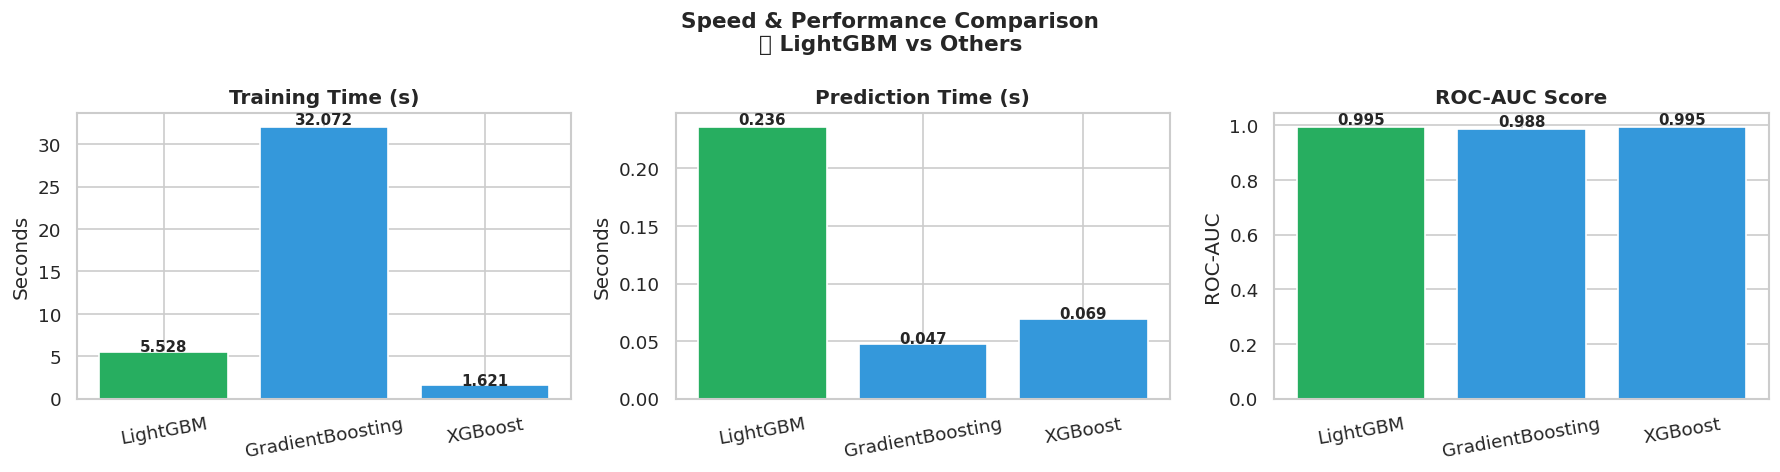

In [47]:
import time
from sklearn.ensemble import GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    has_xgb = True
except:
    has_xgb = False

speed_models = {
    'LightGBM': LGBMClassifier(
        n_estimators = 100,
        random_state = 42,
        n_jobs       = -1,
        verbose      = -1),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators = 100,
        random_state = 42)
}

if has_xgb:
    speed_models['XGBoost'] = XGBClassifier(
        n_estimators      = 100,
        random_state      = 42,
        n_jobs            = -1,
        use_label_encoder = False,
        eval_metric       = 'logloss',
        verbosity         = 0)

speed_results = {}
for name, model in speed_models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    model.predict(X_test)
    pred_time = time.time() - start

    roc_s = roc_auc_score(
        y_test,
        model.predict_proba(X_test)[:, 1])
    speed_results[name] = {
        'train_time': train_time,
        'pred_time' : pred_time,
        'roc_auc'   : roc_s
    }
    print(f"  {name:<20} → "
          f"Train: {train_time:.2f}s  "
          f"Predict: {pred_time:.3f}s  "
          f"ROC: {roc_s:.4f}")

# Speed comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

names  = list(speed_results.keys())
t_time = [speed_results[n]['train_time']
          for n in names]
p_time = [speed_results[n]['pred_time']
          for n in names]
rocs   = [speed_results[n]['roc_auc']
          for n in names]

clrs   = ['#27ae60' if n == 'LightGBM'
          else '#3498db' for n in names]

for ax, vals, title, ylabel in zip(
        axes,
        [t_time, p_time, rocs],
        ['Training Time (s)',
         'Prediction Time (s)',
         'ROC-AUC Score'],
        ['Seconds', 'Seconds', 'ROC-AUC']):
    bars = ax.bar(names, vals,
                  color=clrs,
                  edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.01,
            f'{val:.3f}',
            ha='center', fontsize=9,
            fontweight='bold')

plt.suptitle('Speed & Performance Comparison\n'
             '🌟 LightGBM vs Others',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('LGBM_20_speed_comparison.png',
            bbox_inches='tight')
plt.show()

In [48]:
# Save sklearn format
joblib.dump(lgbm_best,
            'lgbm_airline_model.pkl')
print("✅ LGBM Model (pkl)    → "
      "lgbm_airline_model.pkl")

# Save native LightGBM format
lgbm_best.booster_.save_model(
    'lgbm_airline_model.txt')
print("✅ LGBM Model (txt)    → "
      "lgbm_airline_model.txt")

# Save scaler
joblib.dump(scaler, 'LGBM_scaler.pkl')
print("✅ Scaler              → LGBM_scaler.pkl")

# Save label encoders
joblib.dump(le_dict, 'LGBM_label_encoders.pkl')
joblib.dump(le_target,
            'LGBM_target_encoder.pkl')
print("✅ Label encoders      → "
      "LGBM_label_encoders.pkl")

# Save feature names
pd.DataFrame({
    'features': feature_names
}).to_csv('LGBM_feature_names.csv', index=False)
print("✅ Feature names       → "
      "LGBM_feature_names.csv")

# Save feature importances
imp_split = lgbm_best.booster_.feature_importance(
    importance_type='split')
imp_gain  = lgbm_best.booster_.feature_importance(
    importance_type='gain')

feat_imp_df = pd.DataFrame({
    'Feature'        : feature_names,
    'Split_Imp'      : imp_split,
    'Gain_Imp'       : imp_gain,
    'Permutation_Imp': perm_imp.importances_mean
}).sort_values('Gain_Imp', ascending=False)
feat_imp_df.to_csv(
    'LGBM_feature_importances.csv', index=False)
print("✅ Feature importances → "
      "LGBM_feature_importances.csv")

# Save Native CV results
pd.DataFrame(cv_results).to_csv(
    'LGBM_native_cv_results.csv', index=False)
print("✅ Native CV results   → "
      "LGBM_native_cv_results.csv")

# Save GridSearch results
pd.DataFrame(
    grid_search.cv_results_
).to_csv('LGBM_gridsearch_results.csv',
         index=False)
print("✅ GridSearch results  → "
      "LGBM_gridsearch_results.csv")

# Save threshold analysis
pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall'   : recall[:-1],
    'f1'       : f1
}).to_csv('LGBM_threshold_analysis.csv',
          index=False)
print("✅ Threshold analysis  → "
      "LGBM_threshold_analysis.csv")

# Save speed comparison
pd.DataFrame(speed_results).T.to_csv(
    'LGBM_speed_comparison.csv')
print("✅ Speed comparison    → "
      "LGBM_speed_comparison.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('lgbm_airline_model.pkl')
    files.download('lgbm_airline_model.txt')
    files.download('LGBM_scaler.pkl')
    files.download('LGBM_label_encoders.pkl')
    files.download('LGBM_target_encoder.pkl')
    files.download('LGBM_feature_names.csv')
    files.download('LGBM_feature_importances.csv')
    files.download('LGBM_native_cv_results.csv')
    files.download('LGBM_gridsearch_results.csv')
    files.download('LGBM_threshold_analysis.csv')
    files.download('LGBM_speed_comparison.csv')
    print("\n🎉 All files downloaded!")
except ImportError:
    print("\n📁 Saved locally:")
    print(f"   → "
          f"{os.path.abspath('lgbm_airline_model.pkl')}")
    print(f"   → "
          f"{os.path.abspath('lgbm_airline_model.txt')}")

✅ LGBM Model (pkl)    → lgbm_airline_model.pkl
✅ LGBM Model (txt)    → lgbm_airline_model.txt
✅ Scaler              → LGBM_scaler.pkl
✅ Label encoders      → LGBM_label_encoders.pkl
✅ Feature names       → LGBM_feature_names.csv
✅ Feature importances → LGBM_feature_importances.csv
✅ Native CV results   → LGBM_native_cv_results.csv
✅ GridSearch results  → LGBM_gridsearch_results.csv
✅ Threshold analysis  → LGBM_threshold_analysis.csv
✅ Speed comparison    → LGBM_speed_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded!


In [49]:
# Load pkl format
loaded_pkl = joblib.load(
    'lgbm_airline_model.pkl')

# Load native txt format
loaded_txt = lgb.Booster(
    model_file='lgbm_airline_model.txt')

sample      = X_test.iloc[:6]
predictions = loaded_pkl.predict(sample)
proba       = loaded_pkl.predict_proba(
    sample)[:, 1]
pred_opt    = (proba >= best_thresh).astype(int)
actuals     = y_test.values[:6]

print("\n📊 Predictions:")
print(f"{'#':<4} {'Default(0.5)':<18} "
      f"{'Optimal':<18} "
      f"{'P(Sat)':>8} {'Actual':>14}")
print("-" * 66)

for i, (pred, pred_o,
        prob, actual) in enumerate(
        zip(predictions, pred_opt,
            proba, actuals)):
    d_label = ("🟢 SATISFIED"
               if pred   == 1
               else "🔴 DISSATISFIED")
    o_label = ("🟢 SATISFIED"
               if pred_o == 1
               else "🔴 DISSATISFIED")
    act_lbl = ("SATISFIED"
               if actual == 1
               else "DISSATISFIED")
    correct = "✅" if pred_o == actual else "❌"
    print(f"{i+1:<4} {d_label:<18} "
          f"{o_label:<18} "
          f"{prob*100:>7.2f}% "
          f"{act_lbl:>13} {correct}")

print("\n✅ Both formats loaded and working!")


📊 Predictions:
#    Default(0.5)       Optimal              P(Sat)         Actual
------------------------------------------------------------------
1    🔴 DISSATISFIED     🔴 DISSATISFIED        1.10%  DISSATISFIED ✅
2    🔴 DISSATISFIED     🔴 DISSATISFIED        1.05%  DISSATISFIED ✅
3    🟢 SATISFIED        🟢 SATISFIED          99.53%     SATISFIED ✅
4    🔴 DISSATISFIED     🔴 DISSATISFIED        0.49%  DISSATISFIED ✅
5    🟢 SATISFIED        🟢 SATISFIED          99.97%     SATISFIED ✅
6    🔴 DISSATISFIED     🔴 DISSATISFIED        0.10%  DISSATISFIED ✅

✅ Both formats loaded and working!


In [50]:
print(f"  Dataset               : Airline Satisfaction")
print(f"  Train Shape           : {df_train.shape}")
print(f"  Test Shape            : {df_test.shape}")
print(f"  Total Shape           : {df.shape}")
print(f"  Features Used         : {X.shape[1]}")
print(f"  Training Samples      : {X_train.shape[0]:,}")
print(f"  Test Samples          : {X_test.shape[0]:,}")
print(f"  Satisfied Rate        : {y.mean()*100:.1f}%")
print(f"  Best Parameters       : "
      f"{grid_search.best_params_}")
print(f"  Baseline Accuracy     : {acc_base*100:.2f}%")
print(f"  Tuned Accuracy        : {acc*100:.2f}%")
print(f"  Baseline ROC-AUC      : {roc_base:.4f}")
print(f"  Tuned ROC-AUC         : {roc:.4f}")
print(f"  PR-AUC (Avg Prec)     : {apr:.4f}")
print(f"  CV ROC-AUC            : "
      f"{cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Best F1 Threshold     : {best_thresh:.4f}")
print(f"  Native CV Best Rounds : {best_rounds}")
print(f"  Native CV Best AUC    : {best_cv_auc:.4f}")
print(f"  num_leaves (Best)     : "
      f"{grid_search.best_params_['num_leaves']}")

print(" Saved Files:")
print("   lgbm_airline_model.pkl  ← sklearn format")
print("   lgbm_airline_model.txt  ← native format")
print("   LGBM_scaler.pkl")
print("    LGBM_label_encoders.pkl")
print("   LGBM_target_encoder.pkl")
print("   LGBM_feature_names.csv")
print("   LGBM_feature_importances.csv")
print("   LGBM_native_cv_results.csv")
print("   LGBM_gridsearch_results.csv")
print("   LGBM_threshold_analysis.csv")
print("   LGBM_speed_comparison.csv")
print("   LGBM_01 ~ LGBM_20 PNG files")

  Dataset               : Airline Satisfaction
  Train Shape           : (103904, 25)
  Test Shape            : (25976, 25)
  Total Shape           : (129880, 23)
  Features Used         : 32
  Training Samples      : 103,904
  Test Samples          : 25,976
  Satisfied Rate        : 43.4%
  Best Parameters       : {'colsample_bytree': 0.8, 'learning_rate': 0.07, 'max_depth': 5, 'min_child_samples': 5, 'min_split_gain': 0.01, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 0.8}
  Baseline Accuracy     : 93.91%
  Tuned Accuracy        : 95.65%
  Baseline ROC-AUC      : 0.9812
  Tuned ROC-AUC         : 0.9930
  PR-AUC (Avg Prec)     : 0.9917
  CV ROC-AUC            : 0.9933 ± 0.0005
  Best F1 Threshold     : 0.4187
  Native CV Best Rounds : 500
  Native CV Best AUC    : 0.9953
  num_leaves (Best)     : 15
 Saved Files:
   lgbm_airline_model.pkl  ← sklearn format
   lgbm_airline_model.txt  ← native format
   LGBM_scaler.pkl
    LGBM_label_encoders.pkl
